# Assignement INTRO


```
gDrive_home/
├── Colab Notebooks/
│   └── NLP_assignment/
│       ├── PoliMillionaire.ipynb <-- Your notebook
│       └── millionaire_client/ <-- Directory provided
```


URL: configured via the `api-url` Colab Secret (HTTPS required)

In [ ]:
!pip install langchain
!pip install langchain-huggingface
!pip install -U langchain-community
!pip install json_repair
!pip install -U ddgs

### Game interaction

In [ ]:
from google.colab import drive
import os
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import sys
# Define the path to the directory containing your package
#package_parent_dir = '/content/gdrive/MyDrive/NLP/PoliMillionaire/NLP_assignment/'
package_parent_dir = '/content/gdrive/MyDrive/NLP/Assignment/NLP_assignment_api_client/'

# Append to sys.path if it is not already present
if package_parent_dir not in sys.path:
    sys.path.append(package_parent_dir)

# Verify the path was added
print(sys.path)

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/gdrive/MyDrive/NLP/Assignment/NLP_assignment_api_client/']


Let's import the client classes

In [ ]:
from millionaire_client import MillionaireClient, AuthenticationError

You can save your password in a Colab secret (the "key" icon on the tab on the left) and import it into your notebook.

In [ ]:
from google.colab import userdata
pwd = userdata.get('poli-millionaire')
usr = userdata.get('username')

Now keep the API_URL as stated, but please change the username and password to be the ones you used during sign up session.

In [ ]:
API_URL = userdata.get('api-url')
if not API_URL or not API_URL.startswith("https://"):
    raise ValueError("The quiz API URL must use HTTPS.")
username = usr
password = pwd

Now we can instantiate a MillionaireClient object and call the login method, which takes as parameters username and password.

In [ ]:
client = MillionaireClient(API_URL)
try:
    user = client.login(username, password)
    print(f"\nWelcome, {user.username}! (Role: {user.role})")
except AuthenticationError as e:
    print(f"Login failed: {e}")


Welcome, Rick897! (Role: student)


Types of competition


In [ ]:
# List available competitions
print("\n=== Available Competitions ===")
competitions = client.competitions.list_all()
for comp in competitions:
    print(f"  {comp.id}: {comp.name} ({comp.max_levels} questions)")


=== Available Competitions ===
  0: Entertainment (15 questions)
  1: Ancient History and Politics (15 questions)
  2: Science and Nature (15 questions)
  3: Maths (15 questions)
  4: Philosophy and Psychology (15 questions)
  5: News (15 questions)


In [ ]:
# Choose a competition ID
comp_id = 3
chosen_comp = competitions[comp_id].name
print(f"Chosen competition: {chosen_comp}")

Chosen competition: Maths


## Show Leaderboard


In [ ]:
# Show leaderboard position
lb = client.leaderboard.get(competition_id=comp_id, limit=20)
print(f"\n=== Leaderboard for {lb.competition.name} ===")
for i, entry in enumerate(lb.entries[:10], 1):
    marker = " <-- YOU" if entry.username == username else ""
    print(f"  {i}. {entry.username}: ${entry.score:,.2f} (Level {entry.reached_level}){marker}")


=== Leaderboard for Maths ===
  1. leonfuss: $1,024,000.00 (Level 15)
  2. El_Marzel: $1,024,000.00 (Level 15)
  3. cemalgndzz: $1,024,000.00 (Level 15)
  4. Khashayar: $1,024,000.00 (Level 15)
  5. leonardo_pascotto: $1,024,000.00 (Level 15)
  6. fcaracciolo: $1,024,000.00 (Level 15)
  7. luca_bordin: $1,024,000.00 (Level 15)
  8. Zero37: $1,024,000.00 (Level 15)
  9. chia: $1,024,000.00 (Level 15)
  10. Isak_Hamrin: $1,024,000.00 (Level 15)


# LLMs

## General settings

Models we want to try by category:

Small (< 5B parameters):

*   microsoft/Phi-3.5-mini-instruct (thinking)
*   google/gemma-3-4b-it
*   Qwen/Qwen2.5-3B-Instruct
*   meta-llama/Llama-3.2-3B-Instruct


Medium (5B - 10B parameters):

*   meta-llama/Meta-Llama-3-8B-Instruct (thinking)
*   mistralai/Mistral-7B-v0.3 (non istruct)
*   mistralai/Mistral-7B-Instruct-v0.3
*   google/gemma-2-9b
*   google/gemma-7b-it
*   Qwen/Qwen3.5-9B
*   Qwen/Qwen2.5-7B-Instruct

Large (10B+ parameters):

*   Qwen/Qwen-2.5-14B (non instr)
*   Qwen/Qwen2.5-14B-Instruct
*   google/gemma-2-27b-it

Thinking/Reasoning Models:
* deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B
* deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
* microsoft/Phi-3.5-mini-instruct  (GIA PROVATO )
* Qwen/Qwen2.5-7B-Instruct (GIA PROVATO )

Mixture of Experts / Dense

* mistralai/Mixtral-8x7B-Instruct-v0.1 (pesante 47B)
* Qwen/Qwen1.5-MoE-A2.7B (A-> Active params)
* google/gemma-4-E4B-it (E-> Effective Params)


In [ ]:
MODELS_LIST = [
    "microsoft/Phi-3.5-mini-instruct", #provato
    "microsoft/Phi-4-mini-instruct",
    "google/gemma-3-4b-it",
    "Qwen/Qwen2.5-3B-Instruct", #provato
    "meta-llama/Llama-3.2-3B-Instruct",
    "meta-llama/Meta-Llama-3-8B-Instruct",
    "mistralai/Mistral-7B-v0.3",
    "mistralai/Mistral-7B-Instruct-v0.3",
    "google/gemma-2-9b",
    "google/gemma-7b-it",
    "Qwen/Qwen3.5-9B",
    "Qwen/Qwen2.5-7B-Instruct", #provato
    "Qwen/Qwen-2.5-14B",
    "Qwen/Qwen2.5-14B-Instruct",
    "google/gemma-2-27b-it",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B", #runnabile in q4 , q8
    "Qwen/Qwen1.5-MoE-A2.7B",
    "google/gemma-4-E2B-it",
    "mistralai/Mixtral-8x7B-Instruct-v0.1"
]

STRATEGIES_LIST = [
    "zero_shot",
    "one_shot",
    "few_shot",
    "cot",
    "zero_shot_cot"
]

##CONFIG

In [ ]:
import torch

CONFIG = {
    # SELECT HERE THE MODEL TO RUN
    "model_id": "Qwen/Qwen2.5-3B-Instruct",

    #quantization
    "quantization_bits": 16, # 4, 8 or None to default 16

    # Select here the strategy to apply
    "prompt_strategy": "cot",
    "n-shots": 1 , # set number of examples to give in the prompt
    "temperature": 1.0,
    "do_sample": False,
    # generation
    "max_new_tokens": 512,

    "model_kwargs": {
        "device_map": "auto", # "auto" , "cuda"
        "torch_dtype": "auto",  # "auto", torch.float16, torch.bfloat16, or torch.float32
        "trust_remote_code": True,
        "attn_implementation": "eager",
    }
}

CLASSIFIER_CONFIG = {

    "model_id" : "Qwen/Qwen2.5-3B-Instruct",
    "quantization_bits": None , # 4, 8 or None to default 16
    "max_new_tokens" : 10,
    "temperature" : 0.2,

    "model_kwargs": {
        "device_map": "auto", # "auto" , "cuda"
        "torch_dtype": "auto",  # "auto", torch.float16, torch.bfloat16, or torch.float32
        "trust_remote_code": True,
    }
}

In [ ]:
# VARIABLE TO CONTROL THE LOAD OF THE CLASSIFIER MODEL

CLASSIFIER = False

#LLM loader

##Helper commands


In [ ]:
if CONFIG["model_id"].lower().startswith("microsoft/phi"):
    !pip uninstall -y transformers accelerate
    !pip install transformers==4.43.3 accelerate==0.33.0
    !rm -rf ~/.cache/huggingface/modules

In [ ]:
import torch
import subprocess
import sys

bits = CONFIG.get("quantization_bits")

class_bits = CLASSIFIER_CONFIG.get("quantization_bits")

if bits in {4, 8} or class_bits in {4, 8}:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-U", "transformers", "accelerate", "bitsandbytes"],
        check=True
    )

## Model Loader

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

def load_model(config):
    model_id = config["model_id"]

    kwargs = config["model_kwargs"].copy()

    # quantization
    bits = config.get("quantization_bits")

    if bits == 4:
        kwargs["quantization_config"] = BitsAndBytesConfig(load_in_4bit=True)
    elif bits == 8:
        kwargs["quantization_config"] = BitsAndBytesConfig(load_in_8bit=True)


    display_bits = f"{bits}-bit" if bits else "None (Native/16-bit)"
    print(f"Loading model: {model_id} | Quantization: {display_bits}")

    #  Load Tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        trust_remote_code=kwargs.get("trust_remote_code", False)
    )

    #  Load Model
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        **kwargs
    )

    return tokenizer, model

In [ ]:
# ============================================================
# LOAD MODEL (USING CONFIG)
# ============================================================

llm_tokenizer, llm_model = load_model(CONFIG)

print("Model loaded successfully.")
print("Model name:", CONFIG["model_id"])
print("CUDA available:", torch.cuda.is_available())

try:
    print("Model device:", llm_model.device)
except:
    print("Model device: device_map='auto'")

Loading model: Qwen/Qwen2.5-3B-Instruct | Quantization: 16-bit


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully.
Model name: Qwen/Qwen2.5-3B-Instruct
CUDA available: True
Model device: cuda:0


## Load Classifier

In [ ]:
if CLASSIFIER:
    classifier_tokenizer, classifier_model = load_model(CLASSIFIER_CONFIG)

    print("Classifier model loaded successfully.")
    print("Model name:", CLASSIFIER_CONFIG["model_id"])
    print("CUDA available:", torch.cuda.is_available())

    try:
        print("Model device:", classifier_model.device)
    except:
        print("Model device: device_map='auto'")

else:
    print("Classifier model not loaded.")
    classifier_tokenizer = llm_tokenizer
    classifier_model = llm_model

Classifier model not loaded.


# 🧮 MATH ANSWERING

IMPORT FOR TOOLS USING LANGCHAIN

In [ ]:
import torch
import math
import re
import json
from langchain_core.tools import tool, render_text_description
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.runnables import RunnableConfig, RunnablePassthrough
from typing import Any, Dict, Optional, TypedDict

In [ ]:
import sympy
from sympy.parsing.sympy_parser import (
    parse_expr,
    standard_transformations,
    implicit_multiplication_application,
)

# ── sympy namespace exposed inside the tool ───────────────────────────────────
_SYMPY_LOCALS = {
    "sqrt":      sympy.sqrt,
    "cbrt":      lambda x: sympy.Pow(x, sympy.Rational(1, 3)),
    "Rational":  sympy.Rational,
    "factorial": sympy.factorial,
    "gcd":       sympy.gcd,
    "lcm":       sympy.lcm,
    "floor":     sympy.floor,
    "ceiling":   sympy.ceiling,
    "log":       sympy.log,
    "ln":        sympy.ln,
    "sin":       sympy.sin,
    "cos":       sympy.cos,
    "tan":       sympy.tan,
    "pi":        sympy.pi,
    "E":         sympy.E,
    "I":         sympy.I,
    "oo":        sympy.oo,
    "Mod":       sympy.Mod,
    # calculus / algebra helpers
    "diff":      sympy.diff,
    "integrate": sympy.integrate,
    "solve":     sympy.solve,
    "solveset":  sympy.solveset,
    "limit":     sympy.limit,
    "symbols":   sympy.symbols,
    # equation / expression helpers
    "Eq":        sympy.Eq,
    "expand":    sympy.expand,
    "factor":    sympy.factor,
    "collect":   sympy.collect,
    "Abs":       sympy.Abs,
    # combinatorics
    "binomial":  sympy.binomial,
    # linear algebra
    "Matrix":    sympy.Matrix,
    # numerical fallback
    "nsolve":    sympy.nsolve,
    # pre-bound common symbols
    "x": sympy.Symbol("x"), "y": sympy.Symbol("y"),
    "z": sympy.Symbol("z"), "n": sympy.Symbol("n"),
    "k": sympy.Symbol("k"), "m": sympy.Symbol("m"),
}

##Defining tools

Basic calculator implementation, using eval() function

In [ ]:
@tool
def calculator_basic(expression: str) -> str:
    """
    Use this tool to evaluate complex mathematical expressions.
    """
    try:
        expression = expression.replace("^", "**")
        safe_dict = {
            "abs": abs, "round": round, "min": min, "max": max,
            "math": math, "sqrt": math.sqrt, "pow": pow, "pi": math.pi,
            "sin": math.sin, "cos": math.cos, "tan": math.tan
        }
        result = eval(expression, {"__builtins__": None}, safe_dict)
        return str(result)
    except Exception as e:
        return f"Error evaluating expression. Check your syntax. Details: {e}"


Calculator based on SimPy evaluation function (more advanced)

In [ ]:
@tool
def calculator(expression: str) -> str:
    """
    Evaluate a mathematical expression exactly using sympy.
    Supported syntax:
      ** for powers | sqrt(x) | cbrt(x) for cube root
      Rational(a, b) for exact fractions | factorial(n)
      Mod(a, n) for modular arithmetic | I for the imaginary unit sqrt(-1)
      log(x) | sin(x) | cos(x) | tan(x) | pi | E | gcd(a,b) | lcm(a,b)
      diff(expr, var) | solve(expr, var) | integrate(expr, var) | limit(expr, var, point)
    """
    # Normalise caret-power notation that LLMs often emit (e.g. x^2 → x**2)
    expression = expression.replace("^", "**")
    print(f"    [sympy] parsing: {expression!r}")
    try:
        transformations = standard_transformations + (implicit_multiplication_application,)
        expr_obj = parse_expr(expression, local_dict=_SYMPY_LOCALS,
                              transformations=transformations)
        print(f"    [sympy] parsed tree: {expr_obj}")

        # solve() and similar return a plain Python list — handle without simplify
        if isinstance(expr_obj, (list, tuple)):
            result = ", ".join(str(e) for e in expr_obj)
            print(f"    [sympy] → result (list): {result!r}")
            return result

        simplified = sympy.simplify(expr_obj)
        print(f"    [sympy] simplified: {simplified}")
        try:
            numeric = float(simplified)
            result = str(int(numeric)) if numeric == int(numeric) else f"{numeric:.8g}"
        except (TypeError, ValueError):
            result = str(simplified)
        print(f"    [sympy] → result: {result!r}")
        return result
    except Exception as exc:
        err = f"Error: {exc}"
        print(f"    [sympy] → {err}")
        return err

In [ ]:
tools = [calculator]
rendered_tools = render_text_description(tools)

print(f"Rendered tool text: {rendered_tools}")

Rendered tool text: calculator(expression: str) -> str - Evaluate a mathematical expression exactly using sympy.
Supported syntax:
  ** for powers | sqrt(x) | cbrt(x) for cube root
  Rational(a, b) for exact fractions | factorial(n)
  Mod(a, n) for modular arithmetic | I for the imaginary unit sqrt(-1)
  log(x) | sin(x) | cos(x) | tan(x) | pi | E | gcd(a,b) | lcm(a,b)
  diff(expr, var) | solve(expr, var) | integrate(expr, var) | limit(expr, var, point)


In [ ]:
class ToolCallRequest(TypedDict):
    """A typed dict that shows the inputs into the invoke_tool function."""
    name: str
    arguments: Dict[str, Any]

def invoke_tool(tool_call_request: ToolCallRequest):
    """A function that we can use the perform a tool invocation.

    Args:
        tool_call_request: a dict that contains the keys name and arguments.
            The name must match the name of a tool that exists.
            The arguments are the arguments to that tool.

    Returns:
        output from the requested tool
    """

    tool_name_to_tool = {tool.name: tool for tool in tools}
    name = tool_call_request["name"]
    requested_tool = tool_name_to_tool[name]
    return requested_tool.invoke(tool_call_request["arguments"])

 [Approach] Try to reason on each options and step by step remove the ones that doesn't fit.

 This approach required way more time than we expected --> time out every time

## Defining math prompts

Firstly, we define our small DB of examples to give for few-shots prompting strategy

### Examples for few-shot prompting


In [ ]:
MASTER_EXAMPLES_DB = {
    "arithmetic": [
        {
            "q": "What is (145 * 12) + sqrt(144)?",
            "options": "[1] 1724  [2] 1752  [3] 1800  [4] 1740",
            "expr": "(145 * 12) + sqrt(144)",
            "tool_result_str": "1752, which is option 2.",
            "a": "2"
        },
        {
            "q": "If a company's revenue grows from $250,000 to $312,500, what is the percentage increase?",
            "options": "[1] 20%  [2] 25%  [3] 30%  [4] 15%",
            "expr": "((312500 - 250000) / 250000) * 100",
            "tool_result_str": "25, which is option 2.",
            "a": "2"
        },
        {
            "q": "What is the area of a circle with a radius of 7 meters? (Use pi = 3.14159)",
            "options": "[1] 143.24  [2] 43.98  [3] 153.94  [4] 49.00",
            "expr": "3.14159 * 7^2",
            "tool_result_str": "153.93791, which rounds to 153.94, corresponding to option 3.",
            "a": "3"
        }
    ],
    "theory": [
        {
            "q": "Which of the following describes a tautology in propositional logic?",
            "options": "[1] A statement that is always false\n[2] A statement that is always true\n[3] A statement whose truth value depends on the components\n[4] An unprovable statement assumed to be true",
            "a": "2"
        },
        {
            "q": "According to the Mean Value Theorem, if a function f is continuous on [a, b] and differentiable on (a, b), then there exists at least one c in (a, b) such that:",
            "options": "[1] f'(c) = 0\n[2] f'(c) = (f(b) - f(a)) / (b - a)\n[3] f(c) = 0\n[4] f'(c) = f(b) - f(a)",
            "a": "2"
        },
        {
            "q": "Which property states that for any real numbers a and b, a + b = b + a?",
            "options": "[1] Associative Property\n[2] Distributive Property\n[3] Commutative Property\n[4] Identity Property",
            "a": "3"
        },
        {
            "q": "If two events A and B are independent, which of the following equations must hold true?",
            "options": "[1] P(A and B) = P(A) + P(B)\n[2] P(A or B) = P(A) * P(B)\n[3] P(A and B) = P(A) * P(B)\n[4] P(A given B) = P(B)",
            "a": "3"
        },
        {
            "q": "What is the definition of a prime number?",
            "options": "[1] A number divisible by 2\n[2] A whole number greater than 1 whose only divisors are 1 and itself\n[3] Any odd number greater than 1\n[4] A number that can be expressed as a product of two equal integers",
            "a": "2"
        }
    ],
    "logic": [
        {
            "q": "What is the contrapositive of the conditional statement: 'If it rains, then the ground is wet'?",
            "options": "[1] If the ground is wet, then it rains.\n[2] If it does not rain, then the ground is not wet.\n[3] If the ground is not wet, then it does not rain.\n[4] It rains and the ground is not wet.",
            "r": "The contrapositive of P → Q is ¬Q → ¬P. Negating and reversing both clauses gives: 'If the ground is not wet, then it does not rain.'",
            "a": "3"
        },
        {
            "q": "Which of the following represents the negation of the statement: 'For all real numbers x, x^2 >= 0'?",
            "options": "[1] For all real numbers x, x^2 < 0.\n[2] There exists a real number x such that x^2 < 0.\n[3] There exists a real number x such that x^2 >= 0.\n[4] For no real numbers x, x^2 >= 0.",
            "r": "The negation of a universal quantifier (∀x, P(x)) is an existential quantifier with a negated predicate (∃x, ¬P(x)). Thus, 'For all x, x^2 >= 0' becomes 'There exists an x such that x^2 < 0.'",
            "a": "2"
        },
        {
            "q": "The logical expression P ∨ (P ∧ Q) is logically equivalent to which of the following simpler expressions by the Absorption Law?",
            "options": "[1] P\n[2] Q\n[3] P ∧ Q\n[4] True",
            "r": "By the Absorption Law in Boolean algebra and formal logic, the term (P ∧ Q) is entirely contained within P during a disjunction, simplifying the statement P ∨ (P ∧ Q) down to just P.",
            "a": "1"
        },
        {
            "q": "Which valid rule of inference is represented by the argument form: 'P → Q, ¬Q, therefore ¬P'?",
            "options": "[1] Modus Ponens\n[2] Modus Tollens\n[3] Hypothetical Syllogism\n[4] Disjunctive Syllogism",
            "r": "Modus Tollens (denying the consequent) states that if a conditional statement is true and its consequent is false, then its antecedent must also be false.",
            "a": "2"
        },
        {
            "q": "Under which assignment of truth values is the material implication P → Q false?",
            "options": "[1] P is True, Q is True\n[2] P is False, Q is True\n[3] P is False, Q is False\n[4] P is True, Q is False",
            "r": "A material implication P → Q is defined as false if and only if the antecedent (P) is true and the consequent (Q) is false.",
            "a": "4"
        }
    ]
}

In [ ]:
import random

def get_examples(q_type, n=0):
    if n <= 0:
        return ""

    category_list = MASTER_EXAMPLES_DB.get(q_type)
    if not category_list:
        return ""

    sampled = random.sample(category_list, min(n, len(category_list)))
    formatted_examples = []

    for ex in sampled:

        if q_type == "arithmetic":
            example_str = (
                f"## Example\n"
                f"Q: {ex['q']}  {ex['options']}\n"
                f"<tool_call>\n"
                f'{{"name": "calculator", "arguments": {{"expression": "{ex["expr"]}"}}}}\n'
                f"</tool_call>\n\n"
                f"tool_result = {ex['tool_result_str']}\n"
                f"Answer: {ex['a']}"
            )

        elif q_type == "logic":
            example_str = (
                f"## Example\n"
                f"Q: {ex['q']}\n"
                f"Options:\n{ex['options']}\n"
                f"Reasoning: {ex['r']}\n"
                f"Answer: {ex['a']}"
            )

        elif q_type == "theory":
            example_str = (
                f"## Example\n"
                f"Q: {ex['q']}\n"
                f"Options:\n{ex['options']}\n"
                f"Answer: {ex['a']}"
            )

        formatted_examples.append(example_str)

    return "\n\n".join(formatted_examples)

In [ ]:
# PROMPT FOR INITIAL QUESTION CLASSIFICATION
ROUTER_PROMPT = """
You are a classifier for math multiple-choice questions.
Classify the question into EXACTLY ONE of these three categories:

- arithmetic  → calculations, algebraic manipulation, numeric computation
- logic       → reasoning, deductions, multi-step thinking, proofs
- theory      → recalling formulas, definitions, theorems, factual knowledge

Rules:
- Your entire response must be a SINGLE word
- That word must be one of: arithmetic, logic, theory
- No punctuation, no explanation, no other text
"""

# PROMPT FOR LOGIC
REASONING_PROMPT = """
You are a math assistant playing a multiple-choice quiz.

Rules:
- Solve step-by-step briefly.
- Use concise reasoning.
- Think efficiently and minimize unnecessary explanation.
- Focus only on key deductions.
- Avoid long explanations on obvious reasoning.
- Output your final answer on its own line: Answer: <option number>

"""

# PROMPT FOR ARITHMETIC
CALCULATOR_SYSTEM_PROMPT = f"""
You are a math assistant playing a multiple-choice quiz.
You have access to the following tools:
{rendered_tools}

## Rules
- Use the calculator tool whenever the question requires evaluating an arithmetic expression.
- Emit exactly this structure and wait for the result:

<tool_call>
{{"name": "calculator", "arguments": {{"expression": "<math_expression>"}}}}
</tool_call>

- After receiving the result, elaborate it and output your final answer on its own line: Answer: <option number>
"""

# PROMPT FOR THEORY (must be modified for RAG usage)
THEORY_SYSTEM_PROMPT = """
You are a math theory multiple-choice solver.
Questions may involve theorems, definitions, axioms, properties, logic, algebra, analysis, geometry, probability, or factual mathematical knowledge.

-Answer quickly and directly.
-Avoid long reasoning or step-by-step explanations.
-Use concise high-confidence inference only.
-Output your final answer on its own line: Answer: <option number>
"""

#PROMPT FOR FACT CHECKING ON WEB SEARCH
FACT_CHECKER_SYSTEM_PROMPT = """
You are a mathematics fact-checker.
Your sole task is to determine if the provided web evidence clearly and unambiguously identifies the correct option for the given multiple-choice math question.

Rules:
- If the evidence clearly points to a single correct option, reply exactly in this format: Decision: <option number>
- If the evidence is unclear, ambiguous, missing, conflicting, or insufficient, reply exactly in this format: Decision: UNSURE

Example:
Decision: 2
"""

In [ ]:
#PROMPT OF ONECALL FUNCTION (base prompt)
# starting call prompt onecall
_AGENTIC_SYSTEM = """\
You are a math assistant solving a multiple-choice quiz question.
You have access to a calculator tool that evaluates sympy expressions exactly.

To call the tool, output ONLY a JSON block like this:
```json
{"name": "calculator", "arguments": {"expression": "<sympy expression>"}}
```
Supported syntax inside "sympy expression", DO NOT PUT OTHER THINGS:
      ** for powers | sqrt(x) | cbrt(x) for cube root
      Rational(a, b) for exact fractions | factorial(n)
      Mod(a, n) for modular arithmetic | I for the imaginary unit sqrt(-1)
      log(x) | sin(x) | cos(x) | tan(x) | pi | E | gcd(a,b) | lcm(a,b)
      diff(expr, var) | solve(expr, var) | integrate(expr, var) | limit(expr, var, point)

Use the tool for ANY numerical computation — including modular arithmetic and
imaginary unit powers. After receiving the tool result, reason briefly about
which answer option matches the result (options may be text, not just numbers),
then on the LAST line write exactly:
  Answer: <ID>   (ID is 0, 1, 2, or 3)

If no computation is needed (pure theory), skip the tool and go straight to:
  Answer: <ID>
"""

# PROMPT OF ONECALL FUNCTION (first step prompt)
# planning prompt that gives theory answer only if possible or sequence of functions to be called by the calculator tool (sympy)
PLANNING_PROMPT = """\
Reason step by step:
1. Can this be answered from theory alone, or does it need computation (even simple operations must be done with computations)?
   - If theory only: give your reasoning and end with "Answer: <ID>".
   - If computation needed: state the exact sympy expression to compute in at most 4 lines
     (no named functions like f(x,y), e.g. diff(x**2 - 2*x*y + y**3, x))."""


In [ ]:
# used by the llm answer with classify but no calc
# IF NOT USED ANYMORE (BE SURE), you can delete it
def build_math_prompt_few_shot(question_text, options, question_type):
    options_text = format_options(options)
    examples_block = get_examples(question_type, CONFIG["n-shots"])

    if question_type == 'arithmetic':
        task_hint = (
            "Work through the arithmetic step by step, then output ONLY the option ID.\n"
            "On the last line write: Answer: <ID>"
        )
    elif question_type == 'logic' or question_type == 'theory':
        task_hint = (
            "Analyse each option using mathematical definitions and theorems.\n"
            "On the last line write: Answer: <ID>"
        )

    system_message = (
        "You are playing a multiple-choice math quiz game.\n"
        f"You are an expert of {competitions[COMP_ID].name}.\n"
        "Choose the correct answer for the question delimited by triple backticks.\n\n"
        f"Follow this hint:\n{task_hint}\n"
        f"Examples:\n\n{examples_block}"
    )
    user_message = (
        f"```{question_text}```\n\n"
        f"Options:\n{options_text}\n\n"
        "Answer:"
    )
    return system_message, user_message

In [ ]:
def build_prompt_math(q_type, question_text, options):

    examples_block = get_examples(q_type, CONFIG["n-shots"])

    if q_type == "arithmetic":
        base_prompt = CALCULATOR_SYSTEM_PROMPT
    elif q_type == "logic":
        base_prompt = REASONING_PROMPT
    elif q_type == "theory":
        base_prompt = THEORY_SYSTEM_PROMPT

    system_message = f"{base_prompt}\n\n{examples_block}" #.strip()

    options_text = format_options(options)
    user_message = (
        f"```{question_text}```\n"
        f"Options:\n{options_text}"
    )

    return system_message, user_message

## Extraxt Tool Call <>  tags.

In [ ]:
def extract_tool_call(model_output):

    # Isola ciò che c'è denttro <tool_call> ... </tool_call>
    match = re.search(r"<tool_call>\s*(.*?)\s*</tool_call>", model_output, re.DOTALL)

    if not match:
        return None

    raw_inner_content = match.group(1)

    # Give the JSON content inside the tags to a repair function
    perfect_json = clean_and_repair_tool_json(raw_inner_content)

    if not perfect_json:
        print("[ERROR] Impossible to retreive valid JSON from tags.")
        return None

    return perfect_json

Try to repair the eventual malformed JSON block inside the tool_call tags

In [ ]:
from json_repair import repair_json

def clean_and_repair_tool_json(raw_json_string):

    if not raw_json_string:
        return None

    cleaned = re.sub(r':\s*f(["\'])(.*?)\1', r': "\2"', raw_json_string)

    # Sintactic Repair
    try:
        data = json.loads(cleaned)
    except json.JSONDecodeError:
        try:
            repaired = repair_json(cleaned)
            data = json.loads(repaired)
        except Exception:
            # Se la stringa è troppo corrotta , ritorna None
            return None

    # Se l'output non è un dizionario, non è un tool call valido
    if not isinstance(data, dict):
        return None

    # Estrai il nome del tool (gestendo allucinazioni sul nome del campo)
    tool_name = data.get("name") or data.get("tool") or data.get("function") or "unknown"

    # Estrai gli argomenti (gestendo variazioni di nome)
    raw_args = data.get("arguments") or data.get("args") or data.get("parameters") or {}

    # Se gli argomenti non sono un dizionario (es. il modello ha scritto "arguments": "sin(2)")
    # proviamo a recuperarlo mettendolo nel campo expression
    if not isinstance(raw_args, dict):
        expression_value = str(raw_args)
    else:
        # Cerca il campo expression (o variazioni comuni come 'expr', 'calc', 'value')
        expression_value = (raw_args.get("expression") or raw_args.get("expr") or raw_args.get("value") or  "")

    # Ricostruzione dello schema perfetto ---
    perfect_json = {
        "name": str(tool_name),
        "arguments": {
            "expression": str(expression_value)
        }
    }

    #print(f"Perfect JSON: {perfect_json}")
    return perfect_json

## Helper functions plan
A set of functions used by the ***get_llm_agentic_onecall*** function to parse, check, modify the results according to the sympy calculator tool used, and output a correct response.

In [ ]:
import sympy
from sympy.parsing.sympy_parser import (
    parse_expr,
    standard_transformations,
    implicit_multiplication_application,
)

_TRANSFORMATIONS = standard_transformations + (implicit_multiplication_application,)

# prints a certain label with a separator in between to have a clean view
def print_sep(label=""):
    print(f"  {'─'*20} {label} {'─'*20}" if label else f"  {'─'*50}")

# matches the tool solution to the options (sometimes they are formatted differently)
def match_result_to_option(result_str, options):
    """
    Try to symbolically match a tool result string against each option text.
    Uses sympy with implicit_multiplication so '2*x' matches '2x', etc.
    Returns the matching option ID, or None if no symbolic match is found.
    """
    try:
        result_expr = parse_expr(result_str, transformations=_TRANSFORMATIONS)
    except Exception:
        return None

    for opt in options:
        try:
            opt_expr = parse_expr(opt.text, transformations=_TRANSFORMATIONS)
            if sympy.simplify(result_expr - opt_expr) == 0:
                print(f"  Symbolic match: {result_str!r} == [{opt.id}] {opt.text!r}")
                return opt.id
        except Exception:
            continue
    return None

# validates the expression hints given by the reasoning/planning part as correct sympy parsing
def validate_expr_hint(hint: str) -> bool:
    """
    Dry-run hint through parse_expr + _SYMPY_LOCALS.
    Returns False if unparseable or if it collapses to a plain Python bool
    (which happens when '==' comparisons are used instead of sympy Eq/solve).
    """
    try:
        result = parse_expr(hint, local_dict=_SYMPY_LOCALS,
                            transformations=_TRANSFORMATIONS)
        return not isinstance(result, bool)
    except Exception:
        return False

# returns the think suffix string to avoid the thinking block of deepseek distill models
def get_think_suffix(tokenizer):
  think_suffix = ""
  if CONFIG["model_id"] == "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B" or CONFIG["model_id"] == "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B":
    think_ids = tokenizer.encode("<think>", add_special_tokens=False)
    if len(think_ids) == 1:
      think_suffix = "<think>\n</think>\n"
  return think_suffix

# returns an answer id if present in the output
def find_answer_in_output(output, valid_ids):
  m = re.search(r'Answer[\s:]+([0-9]+)', output, re.IGNORECASE)
  if m:
    ans = int(m.group(1))
    if ans in valid_ids:
      print(f"  Theory answer : {ans}")
      print_sep("ANSWER")
      print(f"  → {ans}")
      return ans

# extracts the calculator expression it found after validating it through another function
def extract_expr_hint(reasoning_output):
  expr_hint = ""
  expr_match = re.search(r'"expression"\s*:\s*"([^"]+)"', reasoning_output)
  if expr_match:
      candidate = expr_match.group(1).strip()
      if validate_expr_hint(candidate):
          expr_hint = candidate
          print(f"  Expr hint     : {expr_hint!r}")
      else:
          print(f"  Expr hint     : discarded (invalid sympy: {candidate!r})")
  return expr_hint

# returns the json tool request and the match
def find_tool_call_json(output):
  tool_match = re.search(
        r'```(?:json)?\s*(\{.*"name"\s*:\s*"calculator".*\})\s*```',
        output, re.DOTALL
    )
  # it may not put the json tag in front sometimes
  if not tool_match:
      tool_match = re.search(
          r'(\{"name"\s*:\s*"calculator".*\})',
          output, re.DOTALL
      )
  tool_request_json = None
  if tool_match:
    raw_json = tool_match.group(1)
    tool_request_json = json.loads(raw_json)
  return tool_match, tool_request_json


##Answer preparation

In [ ]:
def parse_answer(output, valid_ids):

    # First direct check
    match = re.search(r'(?:Answer|Answer is)[\s:]*([0-9]+)', output, re.IGNORECASE)
    if match:
        ans = int(match.group(1))
        if ans in valid_ids:
            return ans

    # Find the last number produced
    numbers = re.findall(r'\b\d+\b', output)
    if numbers:
        ans = int(numbers[-1])
        if ans in valid_ids:
            return ans
    return None

def format_options(options):
    return "\n".join([f"[{opt.id}] {opt.text}" for opt in options])

In [ ]:
def generate_answer(prompt, tokenizer, model, max_new_tokens=600, temperature=0.2):

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[-1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            tokenizer = tokenizer,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=temperature,
            #use_cache = True,
        )

    pruned_output = tokenizer.decode(
        outputs[0][prompt_len:],
        skip_special_tokens=True
    ).strip()

    return pruned_output

## ROUTER CLASSIFIER

Ask the model to classify the questions between CALCULATION / THEORIC. Then give different prompts.

We could have tried to train a specific classifier but a generic LLM already gives decent results

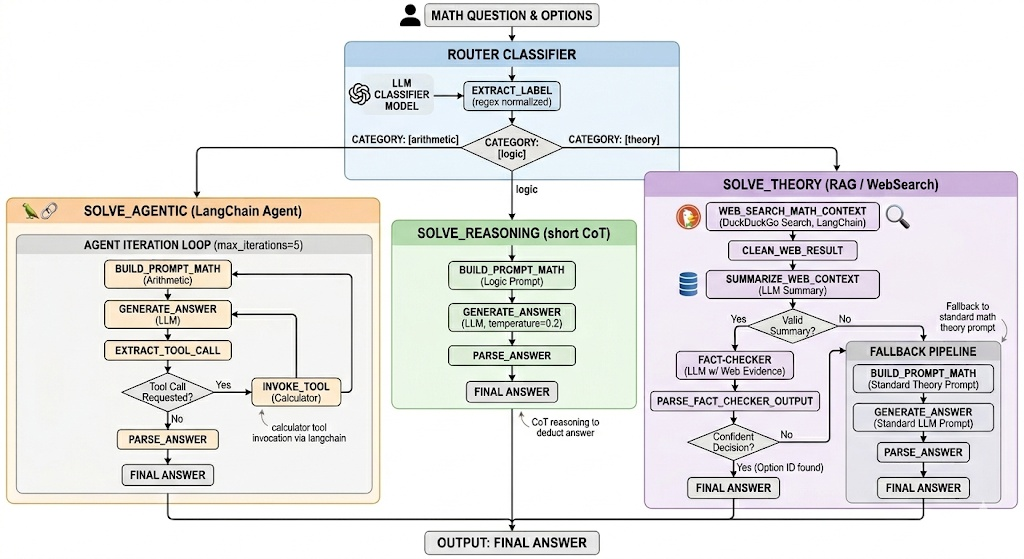

In [ ]:
def extract_label(raw, valid_labels):

    normalized = raw.strip().lower().strip(".,;:!?\"'")

    # Exact match
    if normalized in valid_labels:
        return normalized

    #  Scan for any valid label token in the output
    for label in valid_labels:
        if re.search(rf"\b{label}\b", normalized):
            return label

    #  Fallback
    print(f"Label not recognized from raw output: {repr(raw)} — falling back to 'logic'")
    return "logic"

In [ ]:
# Returns the Question type
def classify_question(question):

    question_text = question.text
    options_text = format_options(question.options)

    user_msg = f"Question: {question_text}\nOptions:\n{options_text}"

    conversation = [
        {"role": "system", "content": ROUTER_PROMPT},
        {"role": "user", "content": user_msg}
    ]

    prompt = classifier_tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)

    raw_label = generate_answer(prompt, classifier_tokenizer, classifier_model, max_new_tokens=CLASSIFIER_CONFIG.get("max_new_tokens"), temperature=CLASSIFIER_CONFIG.get("temperature"))

    valid_labels = ["arithmetic", "logic", "theory"]
    label = extract_label(raw_label, valid_labels)

    print(f"CATEGORY: {label}")
    return label

Route question to proper functions

In [ ]:
# Function called by Play Game
def route_question(question, tokenizer, llm):

    q_type = classify_question(question)

    if q_type == "arithmetic":
        #return get_llm_answer_agentic_onecall(question, tokenizer, model), q_type
        return solve_agentic(q_type, question, tokenizer, llm)

    elif q_type == "logic":
        return solve_reasoning(q_type, question, tokenizer, llm)

    elif q_type == "theory":
        return solve_theory(q_type, question, tokenizer, llm)

### 🤖Arithmetic questions (Calculator)

In [ ]:
def solve_agentic(q_type, question, tokenizer, model, max_iterations=5):

    #Defining the math prompt, according to the classifier
    system_msg, user_msg = build_prompt_math( q_type ,question.text , question.options)

    conversation = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg}
    ]

    #For Debug
    print(f"System message:\n{system_msg}")
    #print(f"User message:\n{user_msg}")

    for iteration in range(max_iterations):

        print("=" * 60)
        print(f"AGENT ITERATION {iteration + 1}")
        print("=" * 60)

        prompt = tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)
        model_output = generate_answer(prompt, tokenizer, model)

        print(f"MODEL OUTPUT: \n{model_output}")

        conversation.append({
            "role": "assistant",
            "content": model_output          # ragionamento + eventuale <tool_call>
        })

        # Check if the model requested a tool call
        tool_call = extract_tool_call(model_output)

        if tool_call is not None:

            print("\nEXECUTING TOOL...\n")
            tool_result = invoke_tool(tool_call)
            print(f"TOOL RESULT: {tool_result}")

            # Append the result to the chat
            conversation.append({
                "role": "user",
                "content": f"tool_result = {tool_result}"
            })
            # Skip the final answer check and move to the next iteration where the result is elaborated
            continue

        # Final answer parsing
        valid_ids = [opt.id for opt in question.options]
        answer = parse_answer(model_output, valid_ids)

        if answer is not None:
            return answer, q_type

        # Last try to get the answer right, if all went wrong
        print("\nFailed to parse tool call or final answer — try to give a generic answer.\n")
        conversation.append({
            "role": "user",
            "content": "Please provide your final answer in the format: Answer: <option number>"
        })

    print("\nMax iterations reached.\n")
    return None, q_type

###📚 Theory questions (RAG/WebSearch)

In [ ]:
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun

# ── Tool Definition ─────────────────────────────────────────────────────

@tool
def search_math_theory(query):
    """
    Web search for mathematical theory context.
    Use this tool when answering theoretical math questions that require
    definitions, theorems, or conceptual explanations.
    Args:
        query: The math concept or theory to search for.
    Returns:
        A string with relevant web search results.
    """
    ddg_search = DuckDuckGoSearchRun()

    return ddg_search.run(query)


# ── Web context helper ──────────────────────────────────────────────────

def web_search_math_context(question_text) :

    # Basic cleanup: remove common conversational filler phrases
    clean_text = re.sub(r'\b(what is|define|explain|describe|give me|can you|the|a|an)\b', '', question_text, flags=re.IGNORECASE)
    search_query = re.sub(r'[^\w\s]', '', clean_text).strip()

    if not search_query:
        search_query = question_text

    try:
        # LangChain tools take arguments directly or via dict depending on schema
        return search_math_theory.invoke(search_query)
    except Exception as e:
        print(f"[WebSearch] Tool invocation failed: {e}")
        return "Search failed"

def clean_web_result(raw) :
    text = re.sub(r'https?://\S+', '', raw)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def summarize_web_context(raw_context, tokenizer, model):
    """Uses the LLM to create a concise, factual summary of the web search results."""

    if not raw_context or "Search failed:" in raw_context:
        return ""

    summary_prompt = (f"""
    Extract and summarize only the relevant mathematical definitions, or
    theorems from this text: {raw_context}
    Be concise and objective."""
    )

    conversation = [{"role": "user", "content": summary_prompt}]
    prompt = tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)
    output = generate_answer(prompt, tokenizer, model, max_new_tokens=512, temperature=0.5)

    print(f"Summary: {output}")
    return output

/tmp/ipykernel_4269/833315680.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [ ]:
def parse_fact_checker_output(output):
    if not output:
        return "UNSURE"

    cleaned = output.strip()

    if re.search(r'decision\s*:?\s*(is)?\s*unsure', cleaned, re.IGNORECASE):
        return "UNSURE"

    # Extract option number limited strictly to [0-3]
    decision_match = re.search(r'decision\s*:?\s*(is|=)?\s*\[?\s*([0-3])', cleaned, re.IGNORECASE)
    if decision_match:
        return int(decision_match.group(2))

    # Last-chance
    if "UNSURE" in cleaned.upper() or "UNCLEAR" in cleaned.upper():
        return "UNSURE"

    return None

In [ ]:
def solve_theory(q_type, question, tokenizer, model):
    valid_ids = [opt.id for opt in question.options]

    # Search the web for the question
    web_context = web_search_math_context(question.text)
    cleaned_search = clean_web_result(web_context)

    print(f"\nRAW WEB SEARCH RESULT: {cleaned_search}\n")

    # Short summarization of the content from the LLM
    web_summary = summarize_web_context(cleaned_search, tokenizer, model)

    use_fallback = False

    # Handle bad/empty web summary right away
    if not web_summary or web_summary.strip() == "":
        use_fallback = True
    else:
        options_text = format_options(question.options)

        system_msg = FACT_CHECKER_SYSTEM_PROMPT
        user_msg = (
            f"```{question.text}```\n"
            f"Options:\n{options_text}"
            f"Web evidence:\n{web_summary}\n\n"
        )

        fc_conversation = [
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ]
        fc_prompt = tokenizer.apply_chat_template(fc_conversation, tokenize=False, add_generation_prompt=True)
        fc_output = generate_answer(fc_prompt, tokenizer, model)

        print(f"\nRAW FACT-CHECKER OUTPUT: {fc_output}\n")

        # Robustly parse the fact-checker output
        decision = parse_fact_checker_output(fc_output)

        # Check if we need to fall back
        if decision == "UNSURE":
            print("[Fact-Checker] Explicit Decision: UNSURE. Fallback.")
            use_fallback = True

        # answer number found
        elif isinstance(decision, int):
            if decision in valid_ids:
                #print(f"\nFinal answer reached confidently via structured Fact-Checker: Option {decision}\n")
                return decision, q_type
            else:
                #print(f"[Fact-Checker] Parsed ID {decision} is out of valid bounds {valid_ids}. Falling back.")
                use_fallback = True
        else:
            print("[Fact-Checker] Formatting structural syntax broke or was completely corrupt. Falling back safely.")
            use_fallback = True

    # Execute Fallback Pipeline if flag is tripped
    if use_fallback:
        print("\nWeb evidence unclear or unavailable. Falling back to standard math theory prompt...\n")
        system_msg, user_msg = build_prompt_math(q_type, question.text, question.options)

    # Generate the final answer
    conversation = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg}
    ]

    prompt = tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)
    model_output = generate_answer(prompt, tokenizer, model, temperature=0.3)

    print("\nMODEL OUTPUT:\n")
    print(model_output)

    answer = parse_answer(model_output, valid_ids)

    if answer is not None:
        print("\nFinal answer reached.\n")
        return answer, q_type

    return answer, q_type

### 🧠Logic questions (short CoT)

In [ ]:
def solve_reasoning(q_type, question, tokenizer, model):

    #Defining the math prompt, according to the classifier
    system_msg, user_msg = build_prompt_math( q_type ,question.text , question.options)

    conversation = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg}
    ]

    prompt = tokenizer.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)

    #print("\nSYSTEM MESSAGE:\n")
    #print(system_msg)

    model_output = generate_answer(prompt, tokenizer, model, temperature=0.2)

    print("\nMODEL OUTPUT:\n")
    print(model_output)

    valid_ids = [opt.id for opt in question.options]
    answer = parse_answer(model_output, valid_ids)

    if answer is not None:
        print("\nFinal answer reached.\n")
        return answer, q_type

    return answer, q_type

## PLAN & CALCULATE
This method builds first a reasoning about the solution to the problem, giving a possible function that solves it, then calls the calculator tool for a given et of steps needed to reach the correct answer.

It converges both theory/logic and arithmetic questions together without the routing procedure, leaving the choice of approach (with small differences) to the reasoning pre-step.

In [ ]:
# zero shot answering method with llm and caluclator tool call
def get_llm_answer_agentic_onecall(question, tokenizer, model,
                               max_turns=3, max_retries=1):
    """
    Agentic math answering pipeline with a reasoning pre-step.

    Flow per attempt:
      Turn 0 (reasoning): LLM analyses the question in a SIDE chain (not kept in
                          main context). If the reasoning concludes with Answer: <ID>
                          (theory path), return immediately. Otherwise extract the
                          sympy expression hint and proceed to action turns.
      Turn 1..max_turns : LLM issues a tool call or a direct answer; after each tool
                          call the result is first checked symbolically against the
                          options - if matched, returns immediately without another
                          LLM call. Otherwise injects the result and continues.
    Falls back to random options if no answer is parsed.
    """
    valid_ids    = [opt.id for opt in question.options]
    options_text = format_options(question.options)

    # DeepSeek-R1 think-block suppression, since the thinking block would exceed time limits
    think_suffix = get_think_suffix(tokenizer)

    # Setting base_messages with the starting system and user prompts
    base_messages = [
        {"role": "system", "content": _AGENTIC_SYSTEM},
        {"role": "user",   "content": (
            f"Question: {question.text}\n\nOptions:\n{options_text}"
        )},
    ]

    # max_retries set to 0 since most of the times one call barely fits the time limit, but based on the quantization, attention, and given tokens it could make more attempts
    for attempt in range(max_retries + 1):
        if attempt > 0:
            print_sep(f"Attempt {attempt}")

        # ── Reasoning pre-turn (side chain — NOT added to main messages) ──────
        print_sep("TURN 0/reasoning")

        reasoning_messages = list(base_messages) + [
            {"role": "user", "content": PLANNING_PROMPT}
        ]
        reasoning_prompt = tokenizer.apply_chat_template(
            reasoning_messages, tokenize=False, add_generation_prompt=True
        ) + think_suffix

        # ── DEBUG (used to see the load of the prompt)
        n_reasoning_tokens = len(tokenizer.encode(reasoning_prompt))
        print(f"  Prompt tokens : {n_reasoning_tokens}")
        # ── DEBUG (used to see the load of the prompt)

        if CONFIG["model_id"] == "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B" or CONFIG["model_id"] == "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B":
          max_new_tokens_reasoning = 256
        elif CONFIG["model_id"] == "Qwen/Qwen2.5-3B-Instruct":
          # given the small number of parameters it could take more reasoning tokens without timing out
          max_new_tokens_reasoning = 768
        else:
          max_new_tokens_reasoning = 512

        print(f"  Max tokens    : {max_new_tokens_reasoning}")

        reasoning_output = generate_answer(
            reasoning_prompt, tokenizer, model,
            do_sample=False, max_new_tokens=max_new_tokens_reasoning
        )
        print(f"  Reasoning     :\n    {reasoning_output!r}")

        # ── Theory path: reasoning already concluded with an answer ──────────
        ans = find_answer_in_output(reasoning_output, valid_ids)
        if ans is not None:
            return ans

        # ── Computation path: extract and validate the expression hint ────────
        expr_hint = extract_expr_hint(reasoning_output)

        # Build the act prompt: short hint only — full reasoning NOT carried forward
        if expr_hint:
            act_content = (
                f"Your reasoning identified the expression: {expr_hint!r}\n\n"
                "Now call the sympy_calculator tool with that expression, "
                "or if no computation is needed write:  Answer: <ID>"
            )
        else:
            act_content = (
                "Now either call the sympy_calculator tool with the exact expression "
                "you need, or if no computation is needed write:  Answer: <ID>\n\n"
                "IMPORTANT: write the FULL algebraic expression — never use named "
                "functions like f(x,y). E.g. diff(x**2 - 2*x*y + y**3, x) not diff(f(x,y), x)."
            )

        # main message chain starts fresh from base_messages + short act prompt
        messages = list(base_messages) + [{"role": "user", "content": act_content}]
        computation_log = []  # accumulates all (expr → result) pairs this attempt

        # ── Tool-call / answer turns ──────────────────────────────────────────
        output = ""
        for turn in range(max_turns):
            print_sep(f"TURN {turn+1}/{max_turns}  (attempt {attempt+1})")

            prompt = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            ) + think_suffix

            # ── DEBUG (used to see the load of the prompt)
            n_prompt_tokens = len(tokenizer.encode(prompt))
            print(f"  Prompt tokens : {n_prompt_tokens}")
            # ── DEBUG (used to see the load of the prompt)

            # max tokens per tool call
            max_new_tokens = 512
            print(f"  Max tokens    : {max_new_tokens}")

            output = generate_answer(prompt, tokenizer, model,
                                     do_sample=False, max_new_tokens=max_new_tokens)
            print(f"  Raw output    :\n    {output!r}")

            # ── Check for tool call ───────────────────────────────────────────
            tool_match, tool_request = find_tool_call_json(output)

            if tool_match:
                try:
                    # extract the calculator expression from the json
                    expr = tool_request.get("arguments", {}).get("expression", "").strip()
                    print(f"  Expression    : {expr!r}")

                    if expr:
                        # ── Invoking the calculator tool ──────────────────────
                        #result = sympy_calculator.invoke({"expression": expr})
                        result = invoke_tool(tool_request)
                        print(f"  Tool result   : {result!r}")

                        # symbolic match against options (e.g. '2*x' == '2x')
                        sym_id = match_result_to_option(result, question.options)
                        if sym_id is not None:
                            print_sep("ANSWER")
                            print(f"  → {sym_id}")
                            return sym_id

                        # Rebuild context with all computations so far
                        computation_log.append(f"{expr} → {result}")
                        log_text = "\n".join(f"  {c}" for c in computation_log)
                        injected = (
                            f"Computations so far:\n{log_text}\n\n"
                            f"Options:\n{options_text}\n\n"
                            "In at most 4 lines, briefly reason on the question options"
                            "and See if more computation is needed, if so, write "
                            "the sympy expressione needed and call the tool again. "
                            "Otherwise on the last line write exactly:  Answer: <ID>"
                        )
                        print(f"  Context reset : {computation_log}")
                        messages = list(base_messages) + [
                            {"role": "user",      "content": act_content},
                            {"role": "assistant", "content": f"Computations so far:\n{log_text}"},
                            {"role": "user",      "content": injected},
                        ]
                        continue  # next turn: model reads result and picks answer
                except Exception as e:
                    print(f"  JSON parse err: {e}")
                    messages.append({"role": "assistant", "content": output})
                    messages.append({"role": "user", "content":
                        "Tool call JSON was malformed. Skip the tool and write:  Answer: <ID>"})
                    continue

            # No tool call detected — output should contain the final answer
            break

        # ── Extract answer ────────────────────────────────────────────────────
        ans = find_answer_in_output(output, valid_ids)
        if ans is not None:
            return ans

        # gets an answer in the last valid numbers of the output
        for n in reversed(re.findall(r'\b([0-9]+)\b', output)):
            ans = int(n)
            if ans in valid_ids:
                print(f"  Last number   : {ans}  (valid)")
                print_sep("ANSWER")
                print(f"  → {ans}")
                return ans

        print(f"  No answer found, nudging model...")
        messages.append({"role": "assistant", "content": output})
        messages.append({"role": "user", "content":
            "End with exactly:  Answer: <ID>"})

        print(f"  Attempt {attempt+1} exhausted all turns.")

    # ── Fallback ──────────────────────────────────────────────────────────────
    # random option fallback
    mid = random.choice(valid_ids)
    print(f"  [fallback] random option: {mid}")
    return mid



## LLM Only, Math
Here we answer math questions directly with the llm without using the calculator tool, but using a different prompt based on the type of question identified by the same classifier used to route the questions in the "router classifier".

ADD IT ONLY IF THE RUNS OF THE MAIN MODEL ARE NOT USEFULL AND MUST BE REDONE. IN THAT CASE USE THIS SINCE IT HAS MORE MATHEMATICAL SENSE.

THIS IS NEEDED TO ANSWER THE QUESTION "if with calc tool the model is better"

In [ ]:
def get_llm_answer_math_no_tool(question, tokenizer, model):
    print("Using answering 'get_llm_answer_math_no_tool'\n") # debug
    valid_ids = [opt.id for opt in question.options]
    qtype = classify_question(question)
    print(f"  [math] type={qtype}")

    system_msg, user_msg = build_math_prompt_few_shot(question.text, question.options, question_type=qtype)
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user",   "content": user_msg},
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Suppress R1 <think> for all types. (i used it mostly on deepseek-ai/DeepSeek-R1-Distill-Qwen-7B)
    # The pre-fill "<think>\n</think>\n" tells R1 the reasoning block is already
    # complete, so it skips to the answer. This only works reliably when the
    # closing tag is a single token in the vocabulary — verify with:
    #   tokenizer.encode("</think>", add_special_tokens=False)
    # If it encodes to more than one token, the suppression won't hold and R1
    # will re-open the block. In that case the model generates ~300-500 extra
    # tokens and will conitnue for a long time. The few-shot examples already supply the
    # reasoning pattern, so suppressing <think> is safe for all types here.
    think_suffix = get_think_suffix(tokenizer)
    prompt += think_suffix

    max_new_tokens = 512

    output = generate_answer(prompt, tokenizer, model, max_new_tokens=max_new_tokens)
    print(f"  [math] raw output: {repr(output)}")

    # Extraction cascade
    # explicit "Answer: N" pattern
    ans = find_answer_in_output(output, valid_ids)
    if ans is not None:
        return ans

    # last valid number in output, sometimes llm models forget the formatting (ex. the answer is 2)
    for n in reversed(re.findall(r'\b([0-9]+)\b', output)):
        ans = int(n)
        if ans in valid_ids:
            print(f"  Parsed answer (last valid number): {ans}")
            return ans

    # random option fallback
    mid = random.choice(valid_ids)
    print(f"  [fallback] random option: {mid}")
    return mid


# TESTING Standardized
ho aggiunto la mia pipeline di testing per omologare i risultati, dovrebbe essere la stessa roba che fai tu comunque.

In [ ]:
COMP_ID = 3

## Manual Test
We give it a set of 4 predetermined math questions to answer.

In [ ]:
import time

# --- Mock API Classes ---
class Option:
    def __init__(self, id, text):
        self.id = id
        self.text = text

class Question:
    def __init__(self, text, options, correct_id):
        self.text = text
        self.options = [Option(id, opt_text) for id, opt_text in options.items()]
        self.correct_id = correct_id

class GameResult:
    def __init__(self, correct, game_over, timed_out, earned_amount):
        self.correct = correct
        self.game_over = game_over
        self.timed_out = timed_out
        self.earned_amount = earned_amount

class Status:
    def __init__(self, value):
        self.value = value

class GameState:
    def __init__(self, status_value):
        self.status = Status(status_value)

class MockGame:
    def __init__(self, questions):
        self.questions = questions
        self.current_level = 1
        self.in_progress = True
        self.earned_amount = 0.0
        self.state = GameState("in_progress")
        self.start_time = time.time()

        # Standard mock money pyramid
        self.prizes = [0, 100, 200, 300, 500, 1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 256000, 512000, 1024000]

    @property
    def current_question(self):
        if self.current_level <= len(self.questions) and self.in_progress:
            return self.questions[self.current_level - 1]
        return None

    @property
    def time_remaining(self):
        # Simulates a 30-second timer per question.
        # (You can increase this if your LLM takes longer during local testing)
        elapsed = time.time() - self.start_time
        remaining = 30.0 - elapsed
        return max(0.0, remaining)

    def answer(self, answer_id):
        if not self.in_progress:
            raise Exception("Game is already over.")

        time_left = self.time_remaining
        if time_left <= 0:
            self.in_progress = False
            self.state.status.value = "timeout"
            return GameResult(correct=False, game_over=True, timed_out=True, earned_amount=self.earned_amount)

        question = self.current_question
        is_correct = (answer_id == question.correct_id)

        if is_correct:
            self.earned_amount = self.prizes[self.current_level]
            if self.current_level == len(self.questions):
                self.in_progress = False
                self.state.status.value = "won"
                return GameResult(correct=True, game_over=True, timed_out=False, earned_amount=self.earned_amount)
            else:
                self.current_level += 1
                self.start_time = time.time() # Reset timer for next question
                return GameResult(correct=True, game_over=False, timed_out=False, earned_amount=self.earned_amount)
        else:
            self.in_progress = False
            self.state.status.value = "lost"
            return GameResult(correct=False, game_over=True, timed_out=False, earned_amount=self.earned_amount)


# --- The LLM Loop ---
def play_game_mock_llm(competition_id, game, tokenizer, model):
    """
    Play the mock game using the LLM to answer automatically.
    """
    # ── Main game loop ────────────────────────────────────────────────────────
    while game.in_progress:
        question = game.current_question
        if not question:
            print("No question available.")
            break

        print(f"\n--- Level {game.current_level} ---")
        print(f"Q: {question.text}\n")
        for opt in question.options:
            print(f"  [{opt.id}] {opt.text}")

        time_left = game.time_remaining
        if time_left:
            print(f"\nTime remaining: {time_left:.1f}s")

        # CHANGE HERE THE SOLVING FUNCTION
        #answer_id = get_llm_answer_agentic_onecall(question, tokenizer, model)
        answer_id = get_llm_answer_math_no_tool(question, tokenizer, model)
        #answer_id, _ = route_question(question, tokenizer, model)

        # Reset timer so LLM inference time doesn't count against the 30s limit
        game.start_time = time.time()

        result = game.answer(answer_id)

        if result.correct:
            print("CORRECT!")
            if result.game_over:
                print("\nCONGRATULATIONS! You won!")
                print(f"Final earnings: ${result.earned_amount:,.2f}")
            else:
                print(f"Earned so far: ${result.earned_amount:,.2f}")
        elif result.timed_out:
            print("TIMED OUT!")
            print(f"Final earnings: ${result.earned_amount:,.2f}")
        else:
            print("WRONG ANSWER!")
            print(f"Final earnings: ${result.earned_amount:,.2f}")

    print("\n=== Game Summary ===")
    print(f"Reached Level  : {game.current_level}")
    print(f"Total Earnings : ${game.earned_amount:,.2f}")
    print(f"Status         : {game.state.status.value}")


# --- Test Custom Questions ---
if __name__ == "__main__":
    # Define your custom questions here to test them manually
    custom_questions = [
        Question(
            text="What is the derivative of x^2?",
            options={0: "x", 1: "2x", 2: "x^2", 3: "2"},
            correct_id=1
        ),
        Question(
            text="Let f(x,y) = x^2 - 2xy + y^3 for all real x and y. Which of the following is true?",
            options={
                0: "f has a relative minimum at (0, 0).",
                1: "f has all of its relative extrema on the parabola x = y^2.",
                2: "f has all of its relative extrema on the line x = y.",
                3: "f has an absolute minimum at (2/3, 2/3)."
            },
            correct_id=2
        ),
        Question(
            text="A total of x feet of fencing is to form three sides of a level rectangular yard. What is the maximum possible area of the yard?",
            options={0: "x^2", 1: "x^2/4", 2: "x^2/9", 3: "x^2/8"},
            correct_id=3
        ),
        Question(
            text="An employment placement agency specializes in placing workers in jobs suited for them. From past experience, the agency knows that 20% of all the workers it places will no longer be at the position in which they were placed after one year; however, only 5% of those remaining after the first year leave during the next year. At the start of a year an employer hires 100 workers using this agency, then at the start of the next year the employer hires 100 more. How many of these 200 workers are expected to be on the job at the end of the second year?",
            options={0: "156", 1: "152", 2: "140", 3: "144"},
            correct_id=0
        )
    ]

    print("=== Starting Mock LLM Test ===")
    print(f"model: {CONFIG['model_id']}")
    print(f"quantization bits: {CONFIG['quantization_bits']}")

    my_mock_game = MockGame(custom_questions)

    play_game_mock_llm(3, game=my_mock_game, tokenizer=llm_tokenizer, model=llm_model)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== Starting Mock LLM Test ===
model: Qwen/Qwen2.5-3B-Instruct
quantization bits: 16

--- Level 1 ---
Q: What is the derivative of x^2?

  [0] x
  [1] 2x
  [2] x^2
  [3] 2

Time remaining: 30.0s
Using answering 'get_llm_answer_math_no_tool'

CATEGORY: arithmetic
  [math] type=arithmetic
  [math] raw output: 'Answer: 1'
  Theory answer : 1
  ──────────────────── ANSWER ────────────────────
  → 1
CORRECT!
Earned so far: $100.00

--- Level 2 ---
Q: Let f(x,y) = x^2 - 2xy + y^3 for all real x and y. Which of the following is true?

  [0] f has a relative minimum at (0, 0).
  [1] f has all of its relative extrema on the parabola x = y^2.
  [2] f has all of its relative extrema on the line x = y.
  [3] f has an absolute minimum at (2/3, 2/3).

Time remaining: 30.0s
Using answering 'get_llm_answer_math_no_tool'

CATEGORY: logic
  [math] type=logic
  [math] raw output: "To determine which statement is true about the function \\( f(x, y) = x^2 - 2xy + y^3 \\), we need to analyze its critical po

## LLM game
Using an LLM model to play the game, by calling `play_game_llm`

In [ ]:
def play_game_llm(competition_id, game, tokenizer, model):
    while game.in_progress:
        question = game.current_question
        if not question:
            print("No question available.")
            break

        print(f"\n--- Level {game.current_level} ---")
        print(f"Q: {question.text}\n")
        for opt in question.options:
            print(f"  [{opt.id}] {opt.text}")

        time_left = game.time_remaining
        if time_left:
            print(f"\nTime remaining: {time_left:.1f}s")

        # changed to type since there are one for each competition
        #answer_id = get_llm_answer_agentic_onecall(question, tokenizer, model)
        answer_id = get_llm_answer_math_no_tool(question, tokenizer, model)
        #answer_id, _ = route_question(question, tokenizer, model)
        print(f"\nLLM answer: {answer_id}")

        result = game.answer(answer_id)

        if result.correct:
            print("CORRECT!")
            if result.game_over:
                print("\nCONGRATULATIONS! You won!")
                print(f"Final earnings: ${result.earned_amount:,.2f}")
            else:
                print(f"Earned so far: ${result.earned_amount:,.2f}")
        elif result.timed_out:
            print("TIMED OUT!")
            print(f"Final earnings: ${result.earned_amount:,.2f}")
        else:
            print("WRONG ANSWER!")
            print(f"Final earnings: ${result.earned_amount:,.2f}")

    print("\n=== Game Summary ===")
    print(f"Reached Level  : {game.current_level}")
    print(f"Total Earnings : ${game.earned_amount:,.2f}")
    print(f"Status         : {game.state.status.value}")


## Run single game
Run this section to play one game.

In [ ]:
# set here the desired competition
# (0 = Entertainment, 1 = History, 2 = Science, 3 = Math)
COMP_ID = 3

In [ ]:
import time

game = client.game.start(competition_id=COMP_ID)
print(f"Session ID   : {game.session_id}")
print(f"Competition  : {game.state.competition.name}")
print()

#play_game_llm(COMP_ID, game, llm_tokenizer, llm_model)
#play_game_agentic_new(game, llm_tokenizer, llm_model)
#play_game_math_banana(COMP_ID, game, llm_tokenizer, llm_model)
print("llm model: "+ str(CONFIG["model_id"]))
print("prompt strategy: "+ str(CONFIG["prompt_strategy"]))
print("quantization: "+ str(CONFIG["quantization_bits"]))
print("temperature: " + str(CONFIG["temperature"]))
#print("attention: " + str(CONFIG["model_kwargs"]["attn_implementation"]))
print()

play_game_llm(COMP_ID, game, llm_tokenizer, llm_model)

Session ID   : 328531
Competition  : Maths

llm model: Qwen/Qwen2.5-3B-Instruct
prompt strategy: cot
quantization: 16
temperature: 1.0


--- Level 1 ---
Q: Find the characteristic of the ring 2Z.

  [0] 12
  [1] 30
  [2] 3
  [3] 0

Time remaining: 29.9s
Using answering 'get_llm_answer_math_no_tool'

CATEGORY: theory
  [math] type=theory
  [math] raw output: "To determine the characteristic of the ring \\(2\\mathbb{Z}\\), we need to understand what the characteristic of a ring is. The characteristic of a ring \\(R\\) is the smallest positive integer \\(n\\) such that \\(n \\cdot 1_R = 0_R\\), where \\(1_R\\) is the multiplicative identity in \\(R\\) and \\(0_R\\) is the additive identity in \\(R\\).\n\nFor the ring \\(2\\mathbb{Z}\\), which consists of all even integers, the multiplicative identity \\(1_{2\\mathbb{Z}}\\) is the integer 1, and the additive identity \\(0_{2\\mathbb{Z}}\\) is the integer 0. We need to find the smallest positive integer \\(n\\) such that \\(n \\cdot 1_{2\\m

## OBT with save
offline benchmark testing on "Qwen14B_benchmark_sbagliate.json"

In [ ]:
#    print(dddddd)



🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
🚀  FULL OFFLINE BENCHMARK  —  no time limit
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
📄 File            : /content/gdrive/MyDrive/NLP/Assignment/Analysis/Qwen14B_benchmark_sbagliate.json
❓ Total in JSON   : 36
✅ With options    : 36
⏭️  Skipped (empty) : 0


════════════════════════════════════════════════════════════════════════════════════════════════════
✅ CORRECT  |  Q001/36  |  Level: 2
────────────────────────────────────────────────────────────────────────────────────────────────────
❓ What is the 5th term in a series in which the first term is 2 and each subsequent term is −2 multiplied by the preceding term?

🎯 Expected  : [1] 32
🤖 Predicted : [1]  32
⏱️  Time      : 13.32s

🔢 Options:
   [0] −16
   [1] 32  <-- ✅ expected | 🤖 predicted
   [2] −32
   [3] 64

────────────────────────────────────────────────────────────────────────────────────────────────────
🧠 MODEL REASONING / DEBUG
───────────────────────────────────────────────────────────────────────────────────────────────

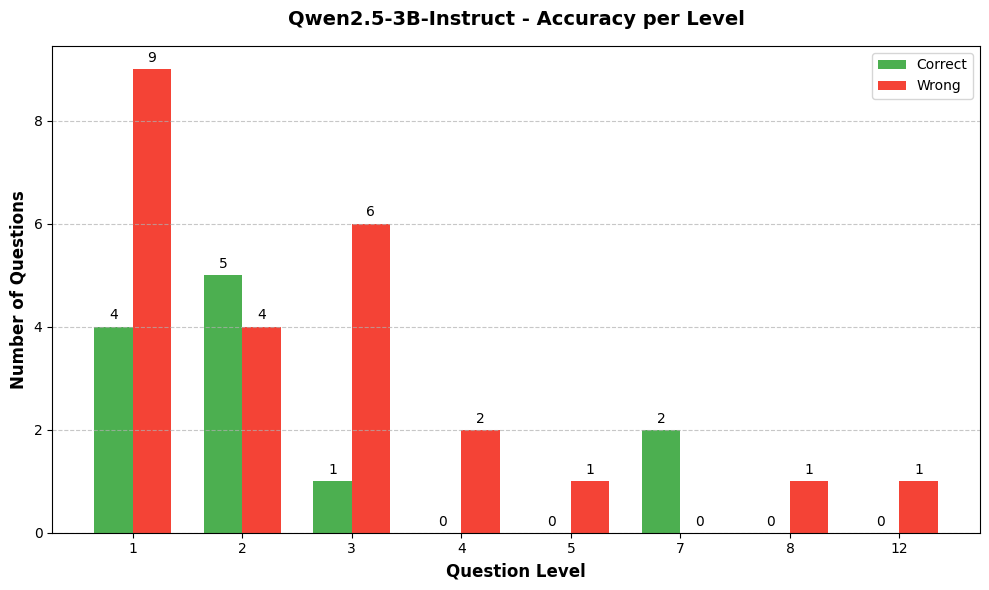

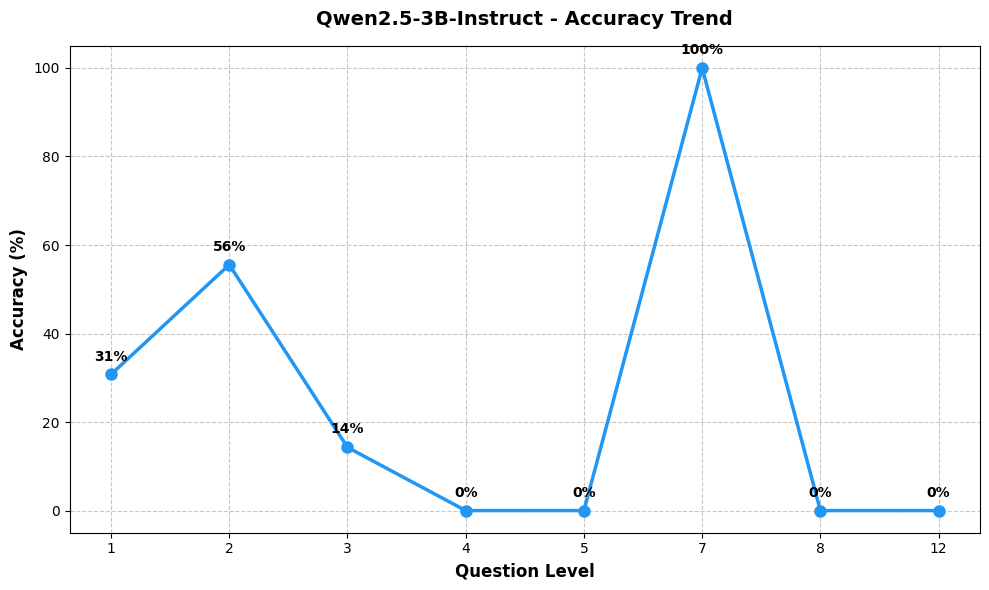


💾 Files saved in: /content/gdrive/MyDrive/NLP/Assignment/Analysis


In [ ]:
import json
import time
import io
import contextlib
import os
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import numpy as np


# ── Mock classes (simulate API objects for offline benchmark) ───────────────

class MockOption:
    def __init__(self, option_id: int, text: str):
        self.id = option_id
        self.text = text

class MockQuestion:
    def __init__(self, text: str, options: dict):
        self.text = text
        self.options = [MockOption(opt_id, opt_text) for opt_id, opt_text in options.items()]


# ── Internal helpers ─────────────────────────────────────────────────────────

def _normalize_prediction(predicted_id):
    if predicted_id is None:
        return -1
    try:
        return int(predicted_id)
    except Exception:
        pass
    for ch in str(predicted_id).strip():
        if ch.isdigit():
            return int(ch)
    return -1

def _short_text(text, max_chars=180):
    text = str(text).replace("\n", " ").strip()
    return text if len(text) <= max_chars else text[:max_chars] + "..."

def _limit_debug_text(text, max_chars=6000):
    text = str(text).strip()
    if len(text) <= max_chars:
        return text
    return text[:max_chars] + "\n\n... DEBUG TRUNCATED (increase RAW_DEBUG_MAX_CHARS to see more) ..."

def _get_option_text(options_dict, option_id):
    return options_dict.get(option_id, "N/A")

def _safe_sort_key(x):
    try:
        return int(x)
    except Exception:
        return str(x)

def _bsep(char="═", length=100):
    print(char * length)

def _safe_config_for_json(cfg):
    """Return a JSON-serializable copy of a config dict."""
    result = {}
    for k, v in cfg.items():
        if isinstance(v, dict):
            result[k] = {
                ik: (iv if isinstance(iv, (str, int, float, bool, type(None))) else str(iv))
                for ik, iv in v.items()
            }
        elif isinstance(v, (str, int, float, bool, type(None))):
            result[k] = v
        else:
            result[k] = str(v)
    return result

# ── Main benchmark function ───────────────────────────────────────────────────

def run_agentic_benchmark(json_path, tokenizer, model,
                          SHOW_OPTIONS_ALWAYS=True,
                          SHOW_RAW_DEBUG_ALWAYS=True,
                          RAW_DEBUG_MAX_CHARS=6000):
    """
    Loads ALL questions from json_path and answers each one with
    get_llm_answer_agentic_new — no time constraint, never stops on a wrong
    answer.  Records per-question timing and prints full analytics at the end.
    Questions with no options are skipped with a warning.
    """

    # ── Load JSON ─────────────────────────────────────────────────────────────
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        print(f"❌ Error loading {json_path}: {e}")
        return None, None

    valid_data = [item for item in data if item.get("options")]
    skipped    = len(data) - len(valid_data)

    print()
    print("🚀" * 20)
    print("🚀  FULL OFFLINE BENCHMARK  —  no time limit")
    print("🚀" * 20)
    print(f"📄 File            : {json_path}")
    print(f"❓ Total in JSON   : {len(data)}")
    print(f"✅ With options    : {len(valid_data)}")
    print(f"⏭️  Skipped (empty) : {skipped}")
    print()

    stats   = defaultdict(lambda: {'correct': 0, 'wrong': 0, 'total': 0})
    records = []
    total_start = time.time()

    for index, item in enumerate(valid_data, start=1):
        q_text           = item.get("question", "")
        level            = item.get("level", 0)
        correct_option_id = item.get("correct_option_id")
        options_dict     = {opt["id"]: opt["text"] for opt in item.get("options", [])}

        mock_q      = MockQuestion(text=q_text, options=options_dict)
        predicted_id = -1
        error        = None
        raw_debug    = ""

        t0 = time.time()
        try:
            buf = io.StringIO()
            with contextlib.redirect_stdout(buf):
                # CHANGE HERE THE SOLVING FUNCTION
                #predicted_raw, _ = route_question(mock_q, tokenizer, model)
                predicted_raw = get_llm_answer_math_no_tool(mock_q, tokenizer, model)
                #predicted_raw = get_llm_answer_agentic_onecall(mock_q, tokenizer, model)
            raw_debug    = buf.getvalue()
            predicted_id = _normalize_prediction(predicted_raw)
        except Exception as e:
            error        = str(e)
            predicted_id = -1
        elapsed = time.time() - t0

        is_correct = (predicted_id == correct_option_id)
        stats[level]['total'] += 1
        if is_correct:
            stats[level]['correct'] += 1
        else:
            stats[level]['wrong'] += 1

        records.append({
            "index"           : index,
            "question"        : q_text,
            "level"           : level,
            "correct_option_id": correct_option_id,
            "predicted_id"    : predicted_id,
            "is_correct"      : is_correct,
            "time_sec"        : elapsed,
            "correct_text"    : _get_option_text(options_dict, correct_option_id),
            "predicted_text"  : _get_option_text(options_dict, predicted_id),
            "options_dict"    : options_dict,
            "error"           : error,
            "raw_debug"       : raw_debug,
        })

        # ── Per-question output ───────────────────────────────────────────────
        icon   = "✅" if is_correct else "❌"
        label  = "CORRECT" if is_correct else "WRONG"
        print()
        _bsep("═")
        print(f"{icon} {label}  |  Q{index:03d}/{len(valid_data)}  |  Level: {level}")
        _bsep("─")
        print(f"❓ {_short_text(q_text, 260)}")
        print()
        print(f"🎯 Expected  : [{correct_option_id}] {_short_text(_get_option_text(options_dict, correct_option_id), 180)}")
        print(f"🤖 Predicted : [{predicted_id}]  {_short_text(_get_option_text(options_dict, predicted_id), 180)}")
        print(f"⏱️  Time      : {elapsed:.2f}s")

        if error:
            print(f"\n⚠️ Error: {error}")

        if SHOW_OPTIONS_ALWAYS:
            print("\n🔢 Options:")
            for opt_id, opt_text in options_dict.items():
                markers = []
                if opt_id == correct_option_id:
                    markers.append("✅ expected")
                if opt_id == predicted_id:
                    markers.append("🤖 predicted")
                suffix = ("  <-- " + " | ".join(markers)) if markers else ""
                print(f"   [{opt_id}] {_short_text(opt_text, 160)}{suffix}")

        if SHOW_RAW_DEBUG_ALWAYS:
            print()
            _bsep("─")
            print("🧠 MODEL REASONING / DEBUG")
            _bsep("─")
            print(_limit_debug_text(raw_debug, RAW_DEBUG_MAX_CHARS) if raw_debug else "(no debug captured)")

        _bsep("═")

    total_elapsed = time.time() - total_start

    # ── Global summary ────────────────────────────────────────────────────────
    total_q       = len(records)
    total_correct = sum(1 for r in records if r["is_correct"])
    total_wrong   = total_q - total_correct
    overall_acc   = (total_correct / total_q * 100) if total_q > 0 else 0
    avg_time      = sum(r["time_sec"] for r in records) / total_q if total_q > 0 else 0

    print()
    print("🏁" * 20)
    print("🏁  FINAL BENCHMARK RESULTS")
    print("🏁" * 20)
    print(f"📌 Questions tested      : {total_q}")
    print(f"✅ Correct               : {total_correct}")
    print(f"❌ Wrong                 : {total_wrong}")
    print(f"🎯 Overall accuracy      : {overall_acc:.1f}%")
    print(f"⏱️  Avg time / question   : {avg_time:.2f}s")
    print(f"⏱️  Total elapsed         : {total_elapsed:.1f}s")

    # ── Per-level recap ───────────────────────────────────────────────────────
    level_time = defaultdict(float)
    for r in records:
        level_time[r["level"]] += r["time_sec"]

    print()
    _bsep("═", 90)
    print("📋 RESULTS BY LEVEL")
    _bsep("═", 90)
    print(f"{'Level':<10} | {'✅ Correct':>10} | {'❌ Wrong':>9} | {'Tot':>5} | {'🎯 Acc':>8} | {'⏱️ Avg s':>9}")
    _bsep("─", 90)
    for lvl in sorted(stats.keys(), key=_safe_sort_key):
        s   = stats[lvl]
        acc = (s['correct'] / s['total'] * 100) if s['total'] > 0 else 0
        at   = level_time[lvl] / s['total'] if s['total'] > 0 else 0
        print(f"{str(lvl):<10} | {s['correct']:>10} | {s['wrong']:>9} | {s['total']:>5} | {acc:>7.1f}% | {at:>8.2f}s")
    _bsep("═", 90)

    # ── Wrong questions list ──────────────────────────────────────────────────
    wrong_records = [r for r in records if not r["is_correct"]]
    print()
    _bsep("═", 100)
    print("❌ WRONG QUESTIONS SUMMARY")
    _bsep("═", 100)
    if not wrong_records:
        print("🎉 All questions answered correctly!")
    else:
        print(f"{'Q':<5} | {'Level':<8} | {'Expected':>10} | {'Predicted':>10} | Question")
        _bsep("─", 100)
        for r in wrong_records:
            print(
                f"{r['index']:<5} | "
                f"{str(r['level']):<8} | "
                f"[{r['correct_option_id']}]".ljust(10) + " | " +
                f"[{r['predicted_id']}]".ljust(10) + " | " +
                _short_text(r['question'], 60)
            )
    _bsep("═", 100)

    # ── SAVING LOGIC ──
    model_name = CONFIG.get('model_id', 'model').split('/')[-1]
    # Return the directory path without the json with all questions
    save_dir = os.path.dirname(json_path)

    # Build output: config at the top, then per-question results
    output = {
        "config" : _safe_config_for_json(CONFIG),
        "results": records,
    }

    # Save JSON
    json_save_path = os.path.join(save_dir, f"{model_name}_no_tool_results_detailed_Rick.json")
    with open(json_save_path, 'w', encoding='utf-8') as f:
        json.dump(output, f, indent=4)

    # ── Plots ─────────────────────────────────────────────────────────────────
    levels_sorted = sorted(stats.keys(), key=_safe_sort_key)
    corrects_plot = [stats[lvl]['correct'] for lvl in levels_sorted]
    wrongs_plot   = [stats[lvl]['wrong']   for lvl in levels_sorted]
    totals_plot   = [stats[lvl]['total']   for lvl in levels_sorted]
    accs_plot     = [(c / t * 100) if t > 0 else 0 for c, t in zip(corrects_plot, totals_plot)]
    x = np.arange(len(levels_sorted))
    w = 0.35

    # Bar Plot
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    b1 = ax1.bar(x - w/2, corrects_plot, w, label='Correct', color='#4CAF50')
    b2 = ax1.bar(x + w/2, wrongs_plot,   w, label='Wrong',   color='#F44336')
    ax1.set_xlabel('Question Level',       fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Questions',  fontsize=12, fontweight='bold')
    ax1.set_title(f'{model_name} - Accuracy per Level',
                  fontsize=14, fontweight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels(levels_sorted)
    ax1.legend()
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.bar_label(b1, padding=3)
    ax1.bar_label(b2, padding=3)
    plt.tight_layout()
    bar_name = f"{model_name} no_tool - plot bar - Rick.png"
    plt.savefig(os.path.join(save_dir, bar_name))
    plt.show()

    # Line Plot
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    ax2.plot(x, accs_plot, marker='o', markersize=8,
             linestyle='-', color='#2196F3', linewidth=2.5)
    ax2.set_xlabel('Question Level',  fontsize=12, fontweight='bold')
    ax2.set_ylabel('Accuracy (%)',    fontsize=12, fontweight='bold')
    ax2.set_title(f'{model_name} - Accuracy Trend',
                  fontsize=14, fontweight='bold', pad=15)
    ax2.set_xticks(x)
    ax2.set_xticklabels(levels_sorted)
    ax2.set_ylim(-5, 105)
    ax2.grid(True, linestyle='--', alpha=0.7)
    for i, (lvl, acc) in enumerate(zip(levels_sorted, accs_plot)):
        ax2.annotate(f"{acc:.0f}%", (i, acc),
                     textcoords="offset points", xytext=(0, 10),
                     ha='center', fontweight='bold')
    plt.tight_layout()
    line_name = f"{model_name} no_tool - plot line - Rick.png"
    plt.savefig(os.path.join(save_dir, line_name))
    plt.show()

    print(f"\n💾 Files saved in: {save_dir}")
    return dict(stats), records


# ── Run ───────────────────────────────────────────────────────────────────────
#change it to yours
#BENCHMARK_JSON_PATH = "/content/gdrive/MyDrive/NLP/PoliMillionaire/Analysis/Qwen14B_benchmark_sbagliate.json"
BENCHMARK_JSON_PATH = "/content/gdrive/MyDrive/NLP/Assignment/Analysis/Qwen14B_benchmark_sbagliate.json"

stats_result, all_records = run_agentic_benchmark(
    json_path  = BENCHMARK_JSON_PATH,
    tokenizer  = llm_tokenizer,
    model      = llm_model,
)

In [ ]:
print(ffff)

NameError: name 'ffff' is not defined

# ANALYSIS Math
Comment:

Classic onecall: in qwen 3b it calls the calculator tool even for questions that 7b param solve just by reasoning, like a question about the derivative of x^2.

Three research questions on the math benchmark runs:

1. **Does adding a calculator tool help with math problems?**
2. **Are "thinking" models better at answering questions than "non-thinking" ones?**
3. **What types of questions do the models tend to struggle on?**

In [ ]:
import os
from pathlib import Path

RUNS_DIR = Path("/content/gdrive/MyDrive/PoliMillionaire/Rick/Analysis Rick")

# Check the contents of the RUNS_DIR
if RUNS_DIR.is_dir():
    print(f"Contents of {RUNS_DIR}:")
    for item in os.listdir(RUNS_DIR):
        print(f"- {item}")
elif RUNS_DIR.exists():
    print(f"{RUNS_DIR} exists but is not a directory.")
else:
    print(f"{RUNS_DIR} does not exist.")

Contents of /content/gdrive/MyDrive/PoliMillionaire/Rick/Analysis Rick:
- Rick version (classic onecall)
- Batu version (classic routing)
- Rick version (llm no_tool)


In [ ]:
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────────────────────────────────
# ANALYSIS MATH v2 — function definitions
# ─────────────────────────────────────────────────────────────────────────────
VARIANT_RENAME = {
    "Rick·tool"    : "Plan & Calculate",
    "Rick·no-tool" : "LLM Only, Math",
    "Batu·routing" : "Routing Classifier",
}

if not df_math.empty:
    df2 = df_math.copy()
    df2["variant_tag"] = df2["variant_tag"].map(VARIANT_RENAME).fillna(df2["variant_tag"])
    df2["run_label"]   = df2.apply(
        lambda r: f"{r.model_short}\n({r.quant_label}) [{r.variant_tag}]", axis=1
    )
else:
    df2 = df_math.copy()

ALL_VARIANTS   = ["Plan & Calculate", "LLM Only, Math", "Routing Classifier"]
TOOL_VARIANTS  = ["Plan & Calculate", "LLM Only, Math", "Routing Classifier"]
THINK_VARIANTS = ["Plan & Calculate"]


def plot_q1():
    """Q1 — Does the execution strategy affect accuracy?"""
    display(Markdown("---\n## Q1 — Does the execution strategy affect accuracy?\n"
                     "> Comparing **Plan & Calculate** (with sympy tool), "
                     "**LLM Only, Math** (no tool, direct answer), and "
                     "**Routing Classifier** (Batu's classic routing approach)."))
    if df2.empty:
        return

    q1_df = df2[df2["variant_tag"].isin(TOOL_VARIANTS)].copy()
    q1_summary = (
        q1_df.groupby(["model_short", "variant_tag"])
        .agg(n=("is_correct", "count"),
             acc=("is_correct", "mean"),
             med_time=("time_sec", "median"),
             mean_time=("time_sec", "mean"))
        .reset_index()
    )

    models_q1 = sorted(q1_summary["model_short"].unique())
    x = np.arange(len(models_q1))
    n_var = len(TOOL_VARIANTS)
    w = 0.22
    colors_q1 = {
        "Plan & Calculate"  : "#4CAF50",
        "LLM Only, Math"    : "#F44336",
        "Routing Classifier": "#FF9800",
    }

    fig1, axes1 = plt.subplots(1, 3, figsize=(20, 5))
    fig1.suptitle("Q1 — Execution strategy: accuracy & speed", fontsize=13, fontweight="bold")

    ax = axes1[0]
    for i, variant in enumerate(TOOL_VARIANTS):
        vals = []
        for m in models_q1:
            row = q1_summary[(q1_summary.model_short == m) & (q1_summary.variant_tag == variant)]
            vals.append(float(row["acc"].values[0]) * 100 if len(row) else float("nan"))
        offset = (i - (n_var - 1) / 2) * w
        bars = ax.bar(x + offset, vals, w, label=variant,
                      color=colors_q1[variant], edgecolor="white")
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, v + 1,
                        f"{v:.0f}%", ha="center", va="bottom", fontsize=7)
    ax.set_title("Accuracy by model & strategy", fontweight="bold")
    ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(models_q1, rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, 115)
    ax.axhline(50, linestyle="--", color="gray", alpha=0.4)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    ax2 = axes1[1]
    agg_acc = (
        q1_df.groupby("variant_tag")
        .agg(acc=("is_correct", "mean"), n=("is_correct", "count"))
        .reindex(TOOL_VARIANTS)
        .reset_index()
    )
    bars2 = ax2.bar(agg_acc["variant_tag"], agg_acc["acc"] * 100,
                    color=[colors_q1[v] for v in agg_acc["variant_tag"]], edgecolor="white")
    for bar, v, n in zip(bars2, agg_acc["acc"] * 100, agg_acc["n"]):
        if pd.notna(v):
            ax2.text(bar.get_x() + bar.get_width() / 2, v + 1,
                     f"{v:.1f}%\n(n={int(n)})", ha="center", va="bottom", fontsize=9)
    ax2.set_title("Aggregated accuracy\n(all models combined)", fontweight="bold")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_ylim(0, 115)
    ax2.axhline(50, linestyle="--", color="gray", alpha=0.4)
    ax2.set_xticklabels(agg_acc["variant_tag"], rotation=15, ha="right", fontsize=9)
    ax2.grid(axis="y", alpha=0.3)

    ax3 = axes1[2]
    for i, variant in enumerate(TOOL_VARIANTS):
        vals = []
        for m in models_q1:
            row = q1_summary[(q1_summary.model_short == m) & (q1_summary.variant_tag == variant)]
            vals.append(float(row["med_time"].values[0]) if len(row) else float("nan"))
        offset = (i - (n_var - 1) / 2) * w
        bars3 = ax3.bar(x + offset, vals, w, label=variant,
                        color=colors_q1[variant], edgecolor="white", alpha=0.85)
        for bar, v in zip(bars3, vals):
            if not np.isnan(v):
                ax3.text(bar.get_x() + bar.get_width() / 2, v + 0.3,
                         f"{v:.1f}s", ha="center", va="bottom", fontsize=7)
    ax3.set_title("Median answer time (s)\nper model & strategy", fontweight="bold")
    ax3.set_ylabel("Time (seconds)")
    ax3.set_xticks(x)
    ax3.set_xticklabels(models_q1, rotation=25, ha="right", fontsize=8)
    ax3.legend(fontsize=8)
    ax3.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nSummary — Q1:")
    print(f"  {'Variant':<22} {'Model':<40} {'Acc':>6}  {'Median(s)':>9}  {'Mean(s)':>8}  n")
    print("  " + "-" * 92)
    for _, r in q1_summary.sort_values(["variant_tag", "model_short"]).iterrows():
        print(f"  {r.variant_tag:<22} {r.model_short:<40} {r.acc*100:>5.1f}%  "
              f"{r.med_time:>8.1f}s  {r.mean_time:>7.1f}s  {int(r.n)}")


def plot_q2():
    """Q2 — Are thinking models better than standard ones?"""
    display(Markdown('---\n## Q2 — Are "thinking" models better than standard ones?\n'
                     '> Using **Plan & Calculate** runs for a fair apples-to-apples comparison.'))
    if df2.empty:
        return

    q2_df = df2[df2["variant_tag"] == "Plan & Calculate"].copy()
    run_order = sorted(
        q2_df["run_label"].unique(),
        key=lambda rl: (not q2_df.loc[q2_df.run_label == rl, "thinking"].iloc[0], rl)
    )
    overall_acc = (
        q2_df.groupby(["run_label", "thinking"])
        .agg(n=("is_correct", "count"),
             acc=("is_correct", "mean"),
             med_time=("time_sec", "median"),
             mean_time=("time_sec", "mean"))
        .reset_index()
        .set_index("run_label")
        .reindex(run_order)
        .reset_index()
    )
    colors_bar = ["#7B1FA2" if t else "#1565C0" for t in overall_acc["thinking"]]
    x_labels   = [rl.replace("\n", " ") for rl in run_order]

    fig2, axes2 = plt.subplots(1, 3, figsize=(20, 5))
    fig2.suptitle("Q2 — Thinking vs standard models (Plan & Calculate runs)",
                  fontsize=13, fontweight="bold")

    ax = axes2[0]
    bars = ax.bar(x_labels, overall_acc["acc"] * 100, color=colors_bar, edgecolor="white")
    for bar, v in zip(bars, overall_acc["acc"] * 100):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.legend(handles=[
        mpatches.Patch(color="#7B1FA2", label="Thinking (DeepSeek-R1)"),
        mpatches.Patch(color="#1565C0", label="Standard (Qwen2.5)"),
    ], fontsize=8)
    ax.set_title("Overall accuracy", fontweight="bold")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 115)
    ax.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=8)
    ax.axhline(50, linestyle="--", color="gray", alpha=0.4)
    ax.grid(axis="y", alpha=0.3)

    ax2b = axes2[1]
    level_group = (
        q2_df.groupby(["thinking", "level"])
        .agg(acc=("is_correct", "mean"))
        .reset_index()
    )
    for thinking_val, color, label in [
            (True,  "#7B1FA2", "Thinking (DeepSeek-R1)"),
            (False, "#1565C0", "Standard (Qwen2.5 avg)"),
    ]:
        sub = level_group[level_group.thinking == thinking_val].sort_values("level")
        if not sub.empty:
            ax2b.plot(sub["level"], sub["acc"] * 100,
                      marker="o", markersize=6, color=color, linewidth=2, label=label)
    ax2b.set_title("Accuracy by question level", fontweight="bold")
    ax2b.set_xlabel("Level (difficulty →)")
    ax2b.set_ylabel("Accuracy (%)")
    ax2b.set_ylim(-5, 110)
    ax2b.axhline(50, linestyle="--", color="gray", alpha=0.4)
    ax2b.legend(fontsize=8)
    ax2b.grid(alpha=0.3)

    ax2c = axes2[2]
    bars_t = ax2c.bar(x_labels, overall_acc["med_time"], color=colors_bar, edgecolor="white")
    for bar, v in zip(bars_t, overall_acc["med_time"]):
        if pd.notna(v):
            ax2c.text(bar.get_x() + bar.get_width() / 2, v + 0.3,
                      f"{v:.1f}s", ha="center", va="bottom", fontsize=9)
    ax2c.set_title("Median answer time (s)\n— does thinking cost more time?", fontweight="bold")
    ax2c.set_ylabel("Median time (seconds)")
    ax2c.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=8)
    ax2c.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nSummary — Q2 (Plan & Calculate):")
    print(f"  {'Model run':<55} {'Type':<10} {'Acc':>6}  {'Med(s)':>7}  {'Mean(s)':>8}  n")
    print("  " + "-" * 100)
    for _, r in overall_acc.iterrows():
        tag = "thinking" if r.thinking else "standard"
        print(f"  {r.run_label.replace(chr(10), ' '):<55} {tag:<10} "
              f"{r.acc*100:>5.1f}%  {r.med_time:>6.1f}s  {r.mean_time:>7.1f}s  {int(r.n)}")


def plot_q3():
    """Q3 — Which question types are hardest and slowest?"""
    display(Markdown("---\n## Q3 — Which question types are hardest — and slowest?\n"
                     "> Accuracy and median answer time broken down by math topic."))
    if df2.empty:
        return

    type_stats = (
        df2.groupby("q_type")
        .agg(n=("is_correct", "count"),
             acc=("is_correct", "mean"),
             med_time=("time_sec", "median"),
             mean_time=("time_sec", "mean"))
        .reset_index()
        .sort_values("acc", ascending=True)
    )

    fig3, axes3 = plt.subplots(1, 3, figsize=(22, 5))
    fig3.suptitle("Q3 — Question type: difficulty & time cost", fontsize=13, fontweight="bold")

    ax = axes3[0]
    bar_colors = ["#F44336" if a < 0.45 else "#FF9800" if a < 0.65 else "#4CAF50"
                  for a in type_stats["acc"]]
    bars = ax.barh(type_stats["q_type"], type_stats["acc"] * 100,
                   color=bar_colors, edgecolor="white")
    for bar, v, n in zip(bars, type_stats["acc"] * 100, type_stats["n"]):
        ax.text(min(v + 1, 115), bar.get_y() + bar.get_height() / 2,
                f"{v:.1f}%  (n={n})", va="center", fontsize=8)
    ax.set_title("Accuracy by question type\n(all runs)", fontweight="bold")
    ax.set_xlabel("Accuracy (%)")
    ax.set_xlim(0, 125)
    ax.axvline(50, linestyle="--", color="gray", alpha=0.5)
    ax.grid(axis="x", alpha=0.3)
    ax.legend(handles=[
        mpatches.Patch(color="#F44336", label="< 45%"),
        mpatches.Patch(color="#FF9800", label="45–65%"),
        mpatches.Patch(color="#4CAF50", label="> 65%"),
    ], fontsize=8, loc="lower right")

    ax2 = axes3[1]
    type_time = type_stats.sort_values("med_time", ascending=True)
    bars2 = ax2.barh(type_time["q_type"], type_time["med_time"], color="#2196F3", edgecolor="white")
    for bar, v in zip(bars2, type_time["med_time"]):
        if pd.notna(v):
            ax2.text(v + 0.2, bar.get_y() + bar.get_height() / 2,
                     f"{v:.1f}s", va="center", fontsize=8)
    ax2.set_title("Median answer time by question type\n(all runs)", fontweight="bold")
    ax2.set_xlabel("Median time (seconds)")
    ax2.grid(axis="x", alpha=0.3)

    ax3 = axes3[2]
    hm_df = df2[df2["variant_tag"] == "Plan & Calculate"]
    pivot = hm_df.pivot_table(index="run_label", columns="level",
                               values="is_correct", aggfunc="mean")
    pivot = pivot[sorted(pivot.columns)]
    row_labels = [rl.replace("\n", " ") for rl in pivot.index]
    cmap = plt.cm.RdYlGn.copy()
    cmap.set_bad(color="#eeeeee")
    masked = np.ma.masked_invalid(pivot.to_numpy(dtype=float))
    im = ax3.imshow(masked, cmap=cmap, aspect="auto", vmin=0, vmax=1)
    ax3.set_xticks(np.arange(len(pivot.columns)))
    ax3.set_xticklabels(pivot.columns, fontsize=7)
    ax3.set_yticks(np.arange(len(pivot.index)))
    ax3.set_yticklabels(row_labels, fontsize=7)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.iloc[i, j]
            if pd.notna(v):
                ax3.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=6,
                         color="black" if 0.25 < v < 0.85 else "white")
    plt.colorbar(im, ax=ax3, label="Accuracy", fraction=0.03, pad=0.02)
    ax3.set_title("Accuracy heatmap: model × level\n(Plan & Calculate runs)", fontweight="bold")
    ax3.set_xlabel("Question level (difficulty →)")

    plt.tight_layout()
    plt.show()

    hard = type_stats[type_stats.acc < 0.55].sort_values("acc")
    slow = type_stats.sort_values("med_time", ascending=False).head(3)
    print("\nHardest question types (accuracy < 55%, all runs):")
    if hard.empty:
        print("  (none)")
    else:
        for _, r in hard.iterrows():
            print(f"  {r.q_type:<30}  acc={r.acc*100:.1f}%  median_time={r.med_time:.1f}s  (n={int(r.n)})")
    print("\nSlowest question types (median time):")
    for _, r in slow.iterrows():
        print(f"  {r.q_type:<30}  median={r.med_time:.1f}s  mean={r.mean_time:.1f}s  acc={r.acc*100:.1f}%")


## Does the execution strategy affect accuracy?
> Comparing **Plan & Calculate** (with SymPy tool), **LLM Only, Math** (no external tool), and **Routing Classifier** (Batu's routing approach). Shows accuracy per model, aggregated accuracy across all models, and median answer time per strategy.

---
## Q1 — Does the execution strategy affect accuracy?
> Comparing **Plan & Calculate** (with sympy tool), **LLM Only, Math** (no tool, direct answer), and **Routing Classifier** (Batu's classic routing approach).

/tmp/ipykernel_1423/2084001697.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(agg_acc["variant_tag"], rotation=15, ha="right", fontsize=9)


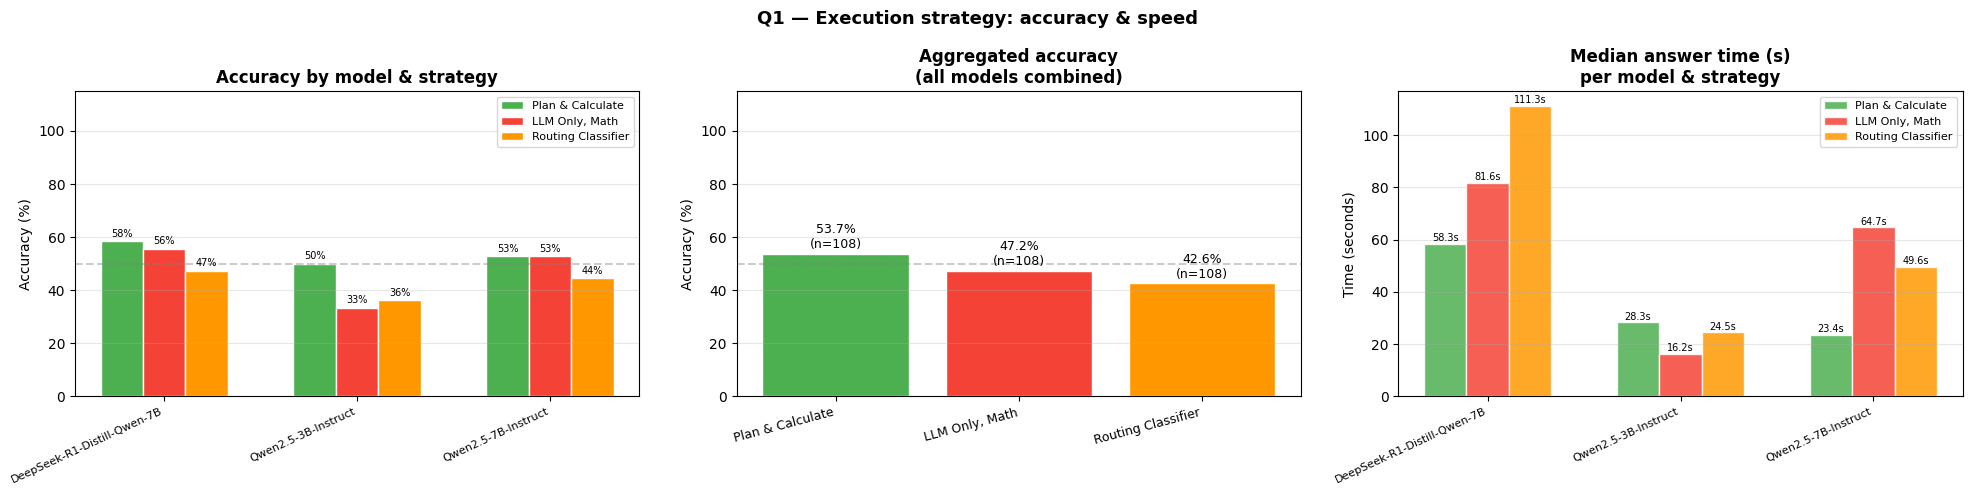


Summary — Q1:
  Variant                Model                                       Acc  Median(s)   Mean(s)  n
  --------------------------------------------------------------------------------------------
  LLM Only, Math         DeepSeek-R1-Distill-Qwen-7B               55.6%      81.6s     73.1s  36
  LLM Only, Math         Qwen2.5-3B-Instruct                       33.3%      16.2s     13.9s  36
  LLM Only, Math         Qwen2.5-7B-Instruct                       52.8%      64.7s     67.2s  36
  Plan & Calculate       DeepSeek-R1-Distill-Qwen-7B               58.3%      58.3s     55.6s  36
  Plan & Calculate       Qwen2.5-3B-Instruct                       50.0%      28.3s     32.1s  36
  Plan & Calculate       Qwen2.5-7B-Instruct                       52.8%      23.4s     28.7s  36
  Routing Classifier     DeepSeek-R1-Distill-Qwen-7B               47.2%     111.3s    152.3s  36
  Routing Classifier     Qwen2.5-3B-Instruct                       36.1%      24.5s     23.5s  36
  Routing

In [ ]:
plot_q1()

## Are "thinking" models better than standard ones?
> Using **Plan & Calculate** runs only, so strategy is kept fixed. Compares DeepSeek-R1 (thinking) against Qwen 2.5 (standard) in overall accuracy, performance by difficulty level, and median answer time.

---
## Q2 — Are "thinking" models better than standard ones?
> Using **Plan & Calculate** runs for a fair apples-to-apples comparison.

/tmp/ipykernel_1423/2084001697.py:173: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=8)
/tmp/ipykernel_1423/2084001697.py:207: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2c.set_xticklabels(x_labels, rotation=25, ha="right", fontsize=8)


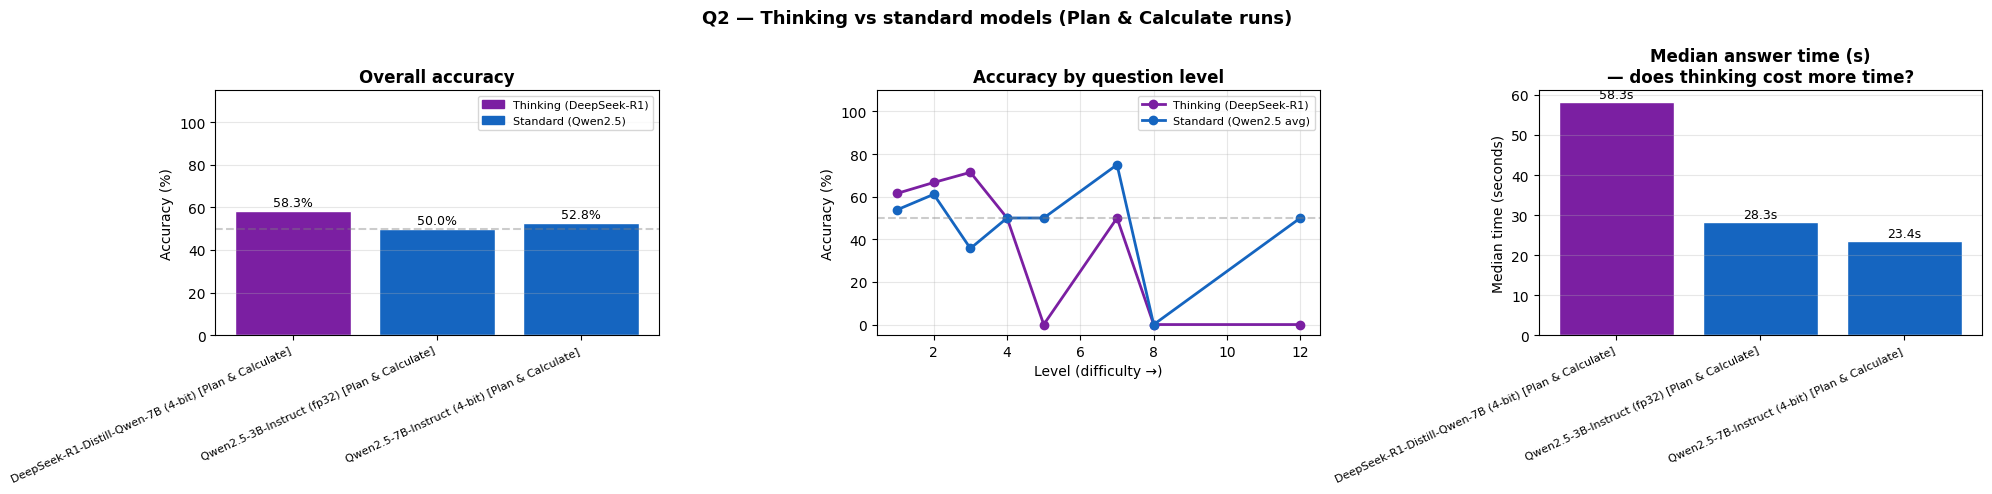


Summary — Q2 (Plan & Calculate):
  Model run                                               Type          Acc   Med(s)   Mean(s)  n
  ----------------------------------------------------------------------------------------------------
  DeepSeek-R1-Distill-Qwen-7B (4-bit) [Plan & Calculate]  thinking    58.3%    58.3s     55.6s  36
  Qwen2.5-3B-Instruct (fp32) [Plan & Calculate]           standard    50.0%    28.3s     32.1s  36
  Qwen2.5-7B-Instruct (4-bit) [Plan & Calculate]          standard    52.8%    23.4s     28.7s  36


In [ ]:
plot_q2()

## Which question types are hardest — and slowest?
> Accuracy and median answer time broken down by math topic (all runs combined). The heatmap shows **Plan & Calculate** accuracy per model × difficulty level.

---
## Q3 — Which question types are hardest — and slowest?
> Accuracy and median answer time broken down by math topic.

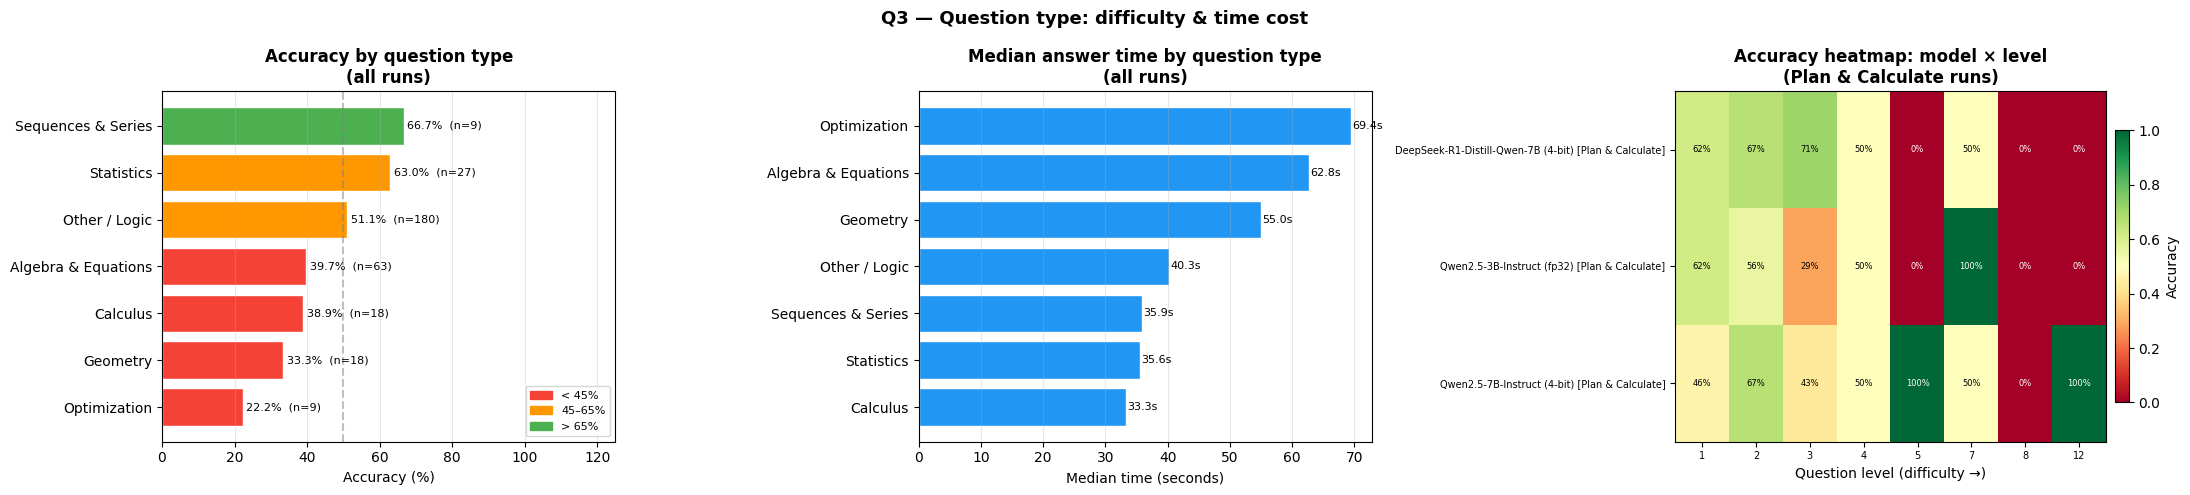


Hardest question types (accuracy < 55%, all runs):
  Optimization                    acc=22.2%  median_time=69.4s  (n=9)
  Geometry                        acc=33.3%  median_time=55.0s  (n=18)
  Calculus                        acc=38.9%  median_time=33.3s  (n=18)
  Algebra & Equations             acc=39.7%  median_time=62.8s  (n=63)
  Other / Logic                   acc=51.1%  median_time=40.3s  (n=180)

Slowest question types (median time):
  Optimization                    median=69.4s  mean=96.3s  acc=22.2%
  Algebra & Equations             median=62.8s  mean=65.4s  acc=39.7%
  Geometry                        median=55.0s  mean=61.8s  acc=33.3%


In [ ]:
plot_q3()